# Proyecto Integrador – RADAR  
## Avance 4: Modelos alternativos

### RADAR  
**Reconocimiento Avanzado de Datos y Análisis de Retail**

Este notebook contiene el desarrollo correspondiente a los primeros modelos alternativos (versiones) del proyecto RADAR, en el cúal se documentan los ajustes o fine tunning realizados al proceso de preprocesamiento y generación de embeddings, definidos a partir del resultado obtenido durante la primer iteración, con el objetivo de mejorar el % de acierto del modelo (53%) tras validaciones manuales de una muestra representativa de los datos.

---

## Equipo

- **Ceja Rodríguez, Lázaro Romel** – A01795989  
- **Chávez Cervantes, Said** – A01114101  
- **Pérez Garza, Javier Alejandro** – A01284386  

---

# **Parte 1**. Desempeño escenario base (RADAR 1.0) (Resultados de la primer aplicación del modelo con el pre-procesamiento e ingeniería de caracteristicas del avance 3)

In [91]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [92]:
import os
DIR = "/content/drive/MyDrive/Proyecto Integrador (RADAR)/Datos/"   # Se establece la ruta (carpeta) donde se sube el archivo descargado del estadístico
os.chdir(DIR)

In [93]:
import pandas as pd
import re
import numpy as np
from numpy.linalg import norm
import random
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics.pairwise import cosine_similarity
import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from scipy import stats
import pickle
import time
import random

In [94]:
# BASE DE DATOS INTERNA (Catalogo de Coppel en la Categoría de Dama)
df_retailer = pd.read_csv('DataDamaJoven.csv', encoding='latin-1')

In [95]:
# Copia de seguridad de la base de datos
df_retailer_original = df_retailer.copy()

In [96]:
# Separar las columnas numericas de las columnas de texto
dfn = df_retailer.select_dtypes(include=np.number).columns.tolist()
dfc = df_retailer.select_dtypes(exclude=np.number).columns.tolist()

In [97]:
# Se eliminan los registros de las clases restantes para reducir la dimensionalidad de las bases de datos a modelar
df_retailer = df_retailer[df_retailer['Clase'] == 'BOLSAS']

In [98]:
# BASE DE DATOS COMPETENCIA
# Se incluyen nombres y descripciones reales para validar la clasificación.
df_competencia = pd.read_csv('bolsas_completo.csv') #Completo_Marcas_Bolsos

In [99]:
# Copia de seguridad de la base de datos
df_competencia_original = df_competencia.copy()

In [100]:
# Eliminar los registros con más de 10 caracteres en las columnas Precio actual y Precio anterior (error en el scrapping)
df_competencia = df_competencia[df_competencia['Precio_actual'].astype(str).str.len() < 10]
df_competencia = df_competencia[df_competencia['Precio_anterior'].astype(str).str.len() < 10]
df_competencia.reset_index(drop=True, inplace=True)

In [101]:
# Convertir la columna Precio actual y Precio anterior de texto a número
df_competencia['Precio_actual'] = df_competencia['Precio_actual'].astype(float)
df_competencia['Precio_anterior'] = df_competencia['Precio_anterior'].astype(float)

In [102]:
# Eliminar las columnas 'Link' y 'Reseñas / Rating' que no se utilizara y contiene un alto porcentaje de valores faltantes.
# Igualar los precios anteriores con valores faltantes al precio actual
# df_competencia.drop(columns=['Link'], inplace=True)
df_competencia['Precio_anterior'].fillna(df_competencia['Precio_actual'], inplace=True)

/tmp/ipykernel_3923/644378432.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_competencia['Precio_anterior'].fillna(df_competencia['Precio_actual'], inplace=True)


In [103]:
# Separar las columnas numericas de las columnas de texto
dfn = df_competencia.select_dtypes(include=np.number).columns.tolist()
dfc = df_competencia.select_dtypes(exclude=np.number).columns.tolist()

In [104]:
# Mostrar información procesada de Coppel
print("\nDimensiones del dataset:")
print(df_retailer.shape)

print("\nPrimeros registros:")
display(df_retailer.head())


Dimensiones del dataset:
(3293, 10)

Primeros registros:


,Codigo,Clase,Familia,Descripcion,Tallas,Marca,Color,Composicion,Precio_reg,Precio_final
0,300028,BOLSAS,DE MANO,FW26 BOLSA CRUZADA CON FULL PRINT COLOR CAFE C...,10,JENNIFER LOPEZ,BROWN,SYNTHETIC 100%.,549,549
1,300039,BOLSAS,DE MANO,ECOM BOLSA GUESS FACTORY HAYWORTH SATCHEL COLO...,10,SIN MARCA,CAFE,PVC 100 %.,2599,2599
2,300042,BOLSAS,DE MANO,ECOM BOLSA GUESS FACTORY NICHOLE SATCHEL,10,GUESS FACTORY,NEGRO,PVC 100 %.,2499,2499
3,300064,BOLSAS,DE MANO,ECOM BOLSA GUESS FACTORY NICHOLE SATCHEL,10,GUESS FACTORY,CAFE,PVC 100 %.,2499,2499
4,300069,BOLSAS,MOCHILA,BOLSA DAMA ESTILO BACK PACK. COLORES NEGRO Y ROJO,10,CLX BY CHRISTIAN LACROIX,ASSORTED,POLYESTER 100%.,549,549


In [105]:
# Mostrar información procesada de la Competencia
print("\nDimensiones del dataset:")
print(df_competencia.shape)

print("\nPrimeros registros:")
display(df_competencia.head())


Dimensiones del dataset:
(6025, 11)

Primeros registros:


,Pagina,Tienda,Marca,Producto,Precio_anterior,Precio_actual,Colores,Descripcion,SKU,Texto_completo,Link
0,10,Suburbia,ZESTINI,Monedero Piaz para mujer,361.0,361.0,Negro | Azul | Rosa | Dorado | Morado,Elegante monedero mediano con un diseño entrec...,Código de Producto: 99993411139,Monedero Piaz para mujer,https://www.suburbia.com.mx/tienda/pdp/moneder...
1,10,Suburbia,ZESTINI,Cosmetiquera multiusos Bella,375.0,375.0,Negro | Azul | Morado | Rosa,Cosmetiquera elaborada con tela muy suave y du...,Código de Producto: 99993419991,Cosmetiquera multiusos Bella,https://www.suburbia.com.mx/tienda/pdp/cosmeti...
2,21,Suburbia,ZADIG & VOLTAIRE,Bolsa shoulder Monnrise de cuero para mujer,9880.0,6916.0,Negro,Bolsa Shoulder Zadig & Voltaire Monnrise color...,Código de Producto: 1195611277,Bolsa shoulder Monnrise de cuero para mujer,https://www.suburbia.com.mx/tienda/pdp/bolsa-s...
3,8,Suburbia,ZADIG & VOLTAIRE,Bolsa crossbody Rock II para mujer,9290.0,7432.0,Negro,Bolsa crossbody Zadig&Voltaire Rock ll de piel...,Código de Producto: 1192281063,Bolsa crossbody Rock II para mujer,https://www.suburbia.com.mx/tienda/pdp/bolsa-c...
4,7,Suburbia,YOIKO,Set de bolsas hobo Esencia para mujer,1429.0,1379.0,Azul | Blanco | Negro | Rojo | Amarillo,Bolso tipo hobo con diseño minimalista y moder...,Código de Producto: 99994913905,Set de bolsas hobo Esencia para mujer,https://www.suburbia.com.mx/tienda/pdp/set-de-...


In [106]:
df_competencia['Tienda'].unique()

array(['Suburbia', 'Liverpool', 'Isadora', 'Lululemon',
       'El Palacio de Hierro', 'Nine West', 'Cloe', 'Herschel',
       'Cuidado con el Perro'], dtype=object)

In [107]:
# Resumen cuantitativo del punto de partida para contextualizar el baseline
n_retailer    = len(df_retailer)
n_competencia = len(df_competencia)
n_familias    = df_retailer['Familia'].nunique()
dim_embedding = 384   # Dimensión fija del modelo paraphrase-multilingual-MiniLM-L12-v2

print("=" * 55)
print("  Configuración del Baseline RADAR 1.0")
print("=" * 55)
print(f"  Productos Coppel (BOLSAS):  {n_retailer:,}")
print(f"  Productos Competencia:      {n_competencia:,}")
print(f"  Familias Coppel disponibles:{n_familias}")
print(f"  Dimensión del embedding:    {dim_embedding}")
print(f"  Modelo:    paraphrase-multilingual-MiniLM-L12-v2")
print(f"  Métrica:   Similitud Coseno")
print(f"  Umbral:    0.70  (a justificar en análisis de sensibilidad)")
print("=" * 55)

  Configuración del Baseline RADAR 1.0
  Productos Coppel (BOLSAS):  3,293
  Productos Competencia:      6,025
  Familias Coppel disponibles:5
  Dimensión del embedding:    384
  Modelo:    paraphrase-multilingual-MiniLM-L12-v2
  Métrica:   Similitud Coseno
  Umbral:    0.70  (a justificar en análisis de sensibilidad)


## Normalización de Tallas y Colores

In [108]:
# Definición de Diccionario Bilingüe con terminos comunes de Ropa y Accesorios

dicc_retail_pro = {
    # BOLSAS & ACCESORIOS
    'bag': 'bolsa', 'handbag': 'bolsa de mano', 'tote': 'de hombro', 'shoulder': 'de hombro', 'backpack': 'mochila',
    'clutch': 'bolsa de mano', 'purse': 'cartera', 'wallet': 'cartera',
    'belt': 'cinturon', 'hat': 'gorra', 'cap': 'gorra', 'scarf': 'bufanda',
    'jewelry': 'joyeria', 'necklace': 'collar', 'sunglasses': 'lentes',

    # BLUSAS, PLAYERAS Y VERANO
    't-shirt': 'playera', 'tshirt': 'playera', 'tee': 'playera', 'tank top': 'tirantes',
    'top': 'blusa', 'shirt': 'camisa', 'blouse': 'blusa', 'camisole': 'camisola',
    'crop top': 'blusa corta', 'sleeveless': 'sin mangas', 'polo': 'playera polo',
    'linen': 'lino', 'fresh': 'fresco', 'summer': 'verano', 'sun': 'sol',

    # VESTIDOS Y PLAYEROS
    'dress': 'vestido', 'gown': 'vestido largo', 'maxi': 'vestido largo',
    'mini': 'vestido corto', 'swimwear': 'traje de bano', 'swimsuit': 'traje de bano',
    'bikini': 'traje de bano', 'bathing suit': 'traje de bano', 'beachwear': 'ropa de playa',
    'short de bano': 'traje de bano', 'pareo': 'playa',

    # INVIERNO Y SOBREPRENDAS
    'jacket': 'chamarra', 'coat': 'abrigo', 'heavy jacket': 'invierno',
    'parka': 'chamarra invierno', 'hoodie': 'sudadera', 'sweatshirt': 'sudadera',
    'sweater': 'sueter', 'cardigan': 'sueter abierto', 'vest': 'chaleco',
    'blazer': 'saco', 'overcoat': 'sobreprenda', 'gabardine': 'gabardina',
    'thermal': 'termico', 'fleece': 'polar', 'windbreaker': 'rompevientos',

    # BOTTOMS (PANTALONES, FALDAS, ETC)
    'pants': 'pantalon', 'trousers': 'pantalon', 'jeans': 'mezclilla',
    'denim': 'mezclilla', 'leggings': 'mallas', 'skirt': 'falda',
    'shorts': 'pantalon corto', 'bermuda': 'pantalon corto', 'jogger': 'pantalon deportivo',

    # MATERIALES Y COMPOSICIÓN
    'cotton': 'algodon', 'polyester': 'poliester', 'leather': 'cuero',
    'faux leather': 'sintetico', 'wool': 'lana', 'silk': 'seda',
    'spandex': 'elastano', 'lycra': 'elastano', 'denim': 'mezclilla',

    # UNIFORMES Y TRABAJO
    'scrubs': 'uniforme medico', 'workwear': 'ropa de trabajo', 'overall': 'overol',
    'apron': 'delantal', 'lab coat': 'bata', 'uniform': 'uniforme'
}

def pipeline_limpieza_pro(text):
    if not isinstance(text, str): return ""

    text = text.lower()

    # Limpieza de Tallas y Basura Numérica
    text = re.sub(r'\b(s|m|l|xl|xxl|xs|2xl|3xl|ch|med|gde|eg|tg|ecom|ecomm)\b', '', text)
    text = re.sub(r'\b\d{5,}\b', '', text) # SKUs largos

    # Caracteres especiales (mantenemos % para composiciones)
    text = re.sub(r'[^a-z0-9áéíóúñ\s%]', ' ', text)

    # Aplicación del Diccionario Bilingüe
    palabras = text.split()
    texto_normalizado = [dicc_retail_pro.get(p, p) for p in palabras]
    text = " ".join(texto_normalizado)

    # Limpieza final de espacios
    text = re.sub(r'\s+', ' ', text).strip()
    return text

1. La construcción de un **diccionario de terminos para retail de textiles en ingles y español** sirve para homologar las distintas formas que pueden emplear los competidores evaluados al nombrar una prenda o accesorio. En el caso particular de Bolsas, se utiliza para que el modelo pueda, por ejemplo, **identificar una equivalencia entre las descripciones que digan backpack con las que digan mochila.** De manera adicional, el construir un **pipeline de limpieza de las descripciones** permitirá eliminar elementos que no aportan contenido semantico relevante cómo lo son etiquetas, tallas, promociones, caracteres especiales, etc.

## Concatenación Semántica

In [109]:
# APLICACIÓN EN RETAILER
# Creamos la columna canónica del retailer concatenando los atributos clave antes de limpiar
df_retailer['canonical_input'] = (
    df_retailer['Descripcion'].fillna('') + " " +
    df_retailer['Marca'].fillna('') + " " +
    df_retailer['Color'].fillna('') + " " +
    df_retailer['Composicion'].fillna('')
)

df_retailer['canonical_input'] = df_retailer['canonical_input'].apply(pipeline_limpieza_pro)

# APLICACIÓN EN COMPETENCIA
# Creamos la columna canónica de la competencia concatenando los atributos clave antes de limpiar
df_competencia['canonical_input'] = (
    df_competencia['Producto'].fillna('') + " " +
    df_competencia['Marca'].fillna('') + " " +
    df_competencia['Colores'].fillna('') + " " +
    df_competencia['Descripcion'].fillna('')
)

df_competencia['canonical_input'] = df_competencia['canonical_input'].apply(pipeline_limpieza_pro)

# Revisión rápida de los primeros resultados
print("Retailer Concatenado:", df_retailer[['canonical_input']].head())
print("Competencia Concatenado:", df_competencia[['canonical_input']].head())

Retailer Concatenado:                                      canonical_input
0  fw26 bolsa cruzada con full print color cafe c...
1  bolsa guess factory hayworth satchel color caf...
2  bolsa guess factory nichole satchel guess fact...
3  bolsa guess factory nichole satchel guess fact...
4  bolsa dama estilo back pack colores negro y ro...
Competencia Concatenado:                                      canonical_input
0  monedero piaz para mujer zestini negro azul ro...
1  cosmetiquera multiusos bella zestini negro azu...
2  bolsa de hombro monnrise de cuero para mujer z...
3  bolsa crossbody rock ii para mujer zadig volta...
4  set de bolsas hobo esencia para mujer yoiko az...


In [110]:
# La cobertura debe medirse sobre el texto CRUDO, antes del pipeline
# porque el diccionario traduce de inglés → español en ese paso

texto_crudo_retailer    = (df_retailer['Descripcion'].fillna('') + " " +
    df_retailer['Marca'].fillna('') + " " +
    df_retailer['Color'].fillna('') + " " +
    df_retailer['Composicion'].fillna('')).str.lower()

texto_crudo_competencia = (df_competencia['Producto'].fillna('') + " " +
    df_competencia['Marca'].fillna('') + " " +
    df_competencia['Colores'].fillna('') + " " +
    df_competencia['Descripcion'].fillna('')).str.lower()

corpus_crudo    = ' '.join(texto_crudo_retailer.tolist() + texto_crudo_competencia.tolist())
tokens_crudo    = set(corpus_crudo.split())
tokens_dicc     = set(dicc_retail_pro.keys())

cobertura_cruda = len(tokens_crudo & tokens_dicc) / len(tokens_crudo) * 100

print(f"Tokens únicos en corpus crudo:    {len(tokens_crudo):,}")
print(f"Tokens cubiertos por diccionario: {len(tokens_crudo & tokens_dicc):,}")
print(f"Cobertura del diccionario:        {cobertura_cruda:.2f}%")
print(f"\nTokens encontrados: {sorted(tokens_crudo & tokens_dicc)}")

Tokens únicos en corpus crudo:    8,490
Tokens cubiertos por diccionario: 24
Cobertura del diccionario:        0.28%

Tokens encontrados: ['backpack', 'bag', 'belt', 'bermuda', 'cap', 'clutch', 'cotton', 'denim', 'fleece', 'handbag', 'jeans', 'jewelry', 'leather', 'maxi', 'mini', 'polo', 'polyester', 'purse', 'shoulder', 'summer', 'sun', 'top', 'tote', 'wallet']


In [111]:
df_retailer[['canonical_input']].head()

,canonical_input
0,fw26 bolsa cruzada con full print color cafe c...
1,bolsa guess factory hayworth satchel color caf...
2,bolsa guess factory nichole satchel guess fact...
3,bolsa guess factory nichole satchel guess fact...
4,bolsa dama estilo back pack colores negro y ro...


,Descripcion,canonical_input
0,FW26 BOLSA CRUZADA CON FULL PRINT COLOR CAFE C...,fw26 bolsa cruzada con full print color cafe c...
1,ECOM BOLSA GUESS FACTORY HAYWORTH SATCHEL COLO...,bolsa guess factory hayworth satchel color caf...
2,ECOM BOLSA GUESS FACTORY NICHOLE SATCHEL,bolsa guess factory nichole satchel guess fact...
3,ECOM BOLSA GUESS FACTORY NICHOLE SATCHEL,bolsa guess factory nichole satchel guess fact...
4,BOLSA DAMA ESTILO BACK PACK. COLORES NEGRO Y ROJO,bolsa dama estilo back pack colores negro y ro...


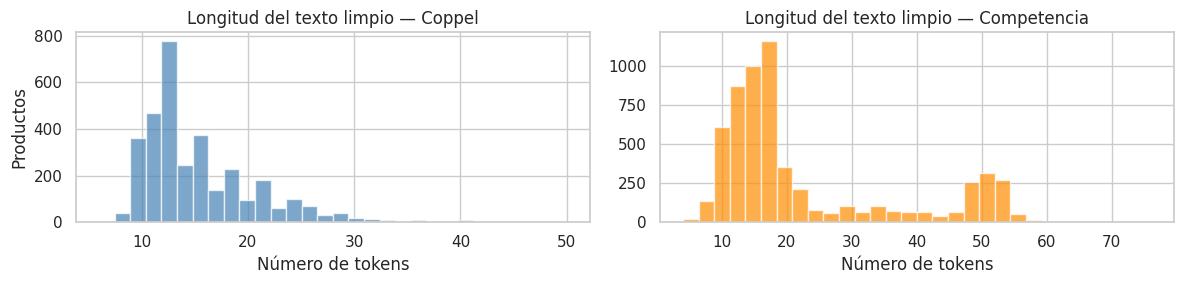

In [112]:
# Muestra comparativa antes y después del pipeline
muestra = df_retailer[['Descripcion', 'canonical_input']].head(5)
display(muestra)

# Distribución de longitud del canonical_input en ambos datasets
fig, axes = plt.subplots(1, 2, figsize=(12, 3), squeeze=False)
axes = axes.ravel()

axes[0].hist(df_retailer['canonical_input'].str.split().str.len(), bins=30, color='steelblue', alpha=0.7)
axes[0].set_title('Longitud del texto limpio — Coppel')
axes[0].set_xlabel('Número de tokens')
axes[0].set_ylabel('Productos')

axes[1].hist(df_competencia['canonical_input'].str.split().str.len(), bins=30, color='darkorange', alpha=0.7)
axes[1].set_title('Longitud del texto limpio — Competencia')
axes[1].set_xlabel('Número de tokens')

plt.tight_layout()
plt.show()

2. Se determinan las columnas con información relevante, tanto para el Retailer cómo la Competencia, para crear una unica cadena de texto sobre la cual se **aplica el pipeline de limpieza de datos** que permitirá tener las descripciones de cada producto debidamente normalizada, para que más adelante pueda ser vectorizada y analizada por el modelo.

## Vectorización

In [113]:
# Cargamos el modelo Bi-Encoder Multilingüe
# Este modelo es ideal para balancear precisión y velocidad de inferencia
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Generación de Embeddings
embeddings_retailer = model.encode(df_retailer['canonical_input'].tolist(),
                                   convert_to_tensor=True,
                                   show_progress_bar=True)

embeddings_competencia = model.encode(df_competencia['canonical_input'].tolist(),
                                      convert_to_tensor=True,
                                      show_progress_bar=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/189 [00:00<?, ?it/s]

3. Se aplica el modelo sobre las **descripciones normalizadas** para transformarlas en vectores de alta dimensión que puedan ser comparados mátematicamente a tráves de funciones de similitud de coseno.

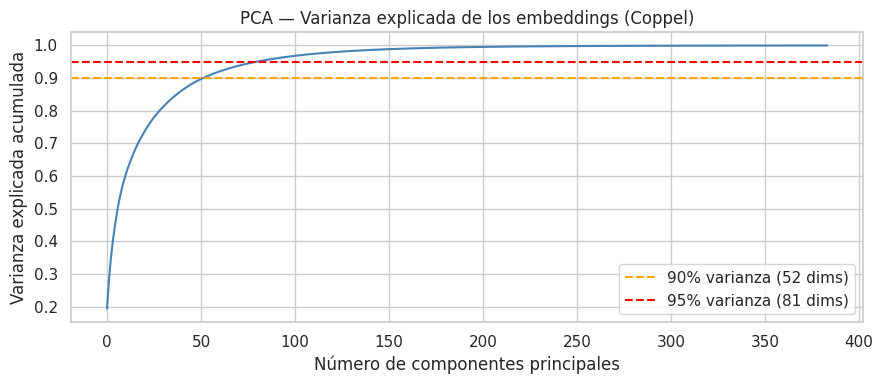

In [114]:
emb_np = embeddings_retailer.detach().cpu().numpy()

pca_full = PCA().fit(emb_np)

# ¿Cuántas dimensiones explican el 90% y 95% de la varianza?
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)
dim_90 = np.argmax(varianza_acumulada >= 0.90) + 1
dim_95 = np.argmax(varianza_acumulada >= 0.95) + 1

plt.figure(figsize=(9, 4))
plt.plot(varianza_acumulada, linewidth=1.5, color='steelblue')
plt.axhline(0.90, color='orange', linestyle='--', label=f'90% varianza ({dim_90} dims)')
plt.axhline(0.95, color='red',    linestyle='--', label=f'95% varianza ({dim_95} dims)')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA — Varianza explicada de los embeddings (Coppel)')
plt.legend()
plt.tight_layout()
plt.show()

In [115]:
def visualize_semantic_clusters(df_retailer, df_competencia, embeddings_retailer, embeddings_competencia, n_samples=200):

    # Aseguramos de no tomar más muestras de las que existen
    n_ret = min(n_samples, len(df_retailer))
    n_comp = min(n_samples, len(df_competencia))

    idx_retailer = random.sample(range(len(df_retailer)), n_ret)
    idx_competencia = random.sample(range(len(df_competencia)), n_comp)

    # Filtrar DataFrames
    df_ret_sample = df_retailer.iloc[idx_retailer].copy()
    df_comp_sample = df_competencia.iloc[idx_competencia].copy()

    # Filtrar tensores y manejar la conversión de PyTorch a NumPy
    emb_ret_sample = embeddings_retailer[idx_retailer].detach().cpu().numpy()
    emb_comp_sample = embeddings_competencia[idx_competencia].detach().cpu().numpy()

    # Concatenar embeddings
    X = np.vstack((emb_ret_sample, emb_comp_sample))

    # Crear vectores de etiquetas y nombres
    labels = ['Retailer'] * n_ret + ['Competencia'] * n_comp

    # Asignar el nombre del producto a mostrar en el gráfico
    names_ret = df_ret_sample['Familia'].tolist()
    names_comp = df_comp_sample['Producto'].tolist()
    product_names = names_ret + names_comp

    # Reducción con T-SNE
    start_time = time.time()

    tsne_model = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate='auto',
        init='pca',
        random_state=42 # Para reproducibilidad
    )

    X_tsne = tsne_model.fit_transform(X)

    end_time = time.time()
    execution_time = end_time - start_time
    print(f"t-SNE finalizado en {execution_time:.2f} segundos.")

    # Preparar DataFrame para Seaborn
    df_viz = pd.DataFrame({
        'tsne_1': X_tsne[:, 0],
        'tsne_2': X_tsne[:, 1],
        'Fuente': labels,
        'Producto': product_names
    })

    # Configurar estilo de la gráfica
    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid")

    # Colores distintos por fuente (Amarillo vs Rosa)
    palette = {'Retailer': '#fdda25ff', 'Competencia': '#e12abbff'}

    # Scatter Plot con transparencia para ver solapamientos
    ax = sns.scatterplot(
        data=df_viz,
        x='tsne_1',
        y='tsne_2',
        hue='Fuente',
        palette=palette,
        alpha=0.6,
        s=80,
        edgecolor='w',
        linewidth=0.5
    )

    # Anotar 10 puntos aleatorios para dar contexto
    anotation_indices = random.sample(range(len(df_viz)), 10)
    for idx in anotation_indices:
        plt.annotate(
            df_viz['Producto'].iloc[idx],
            (df_viz['tsne_1'].iloc[idx], df_viz['tsne_2'].iloc[idx]),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            color='black',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0")
        )

    # Formateo final (Títulos, Leyenda y Ejes normalizados)
    plt.title('Proyección t-SNE de Similitud Semántica: Retailer vs Competencia', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Dimensión t-SNE 1', fontsize=12)
    plt.ylabel('Dimensión t-SNE 2', fontsize=12)
    plt.legend(title='Catálogo', loc='best', fontsize=10)

    # Normalización visual de ejes (Tight layout)
    plt.tight_layout()
    plt.show()

t-SNE finalizado en 3.84 segundos.


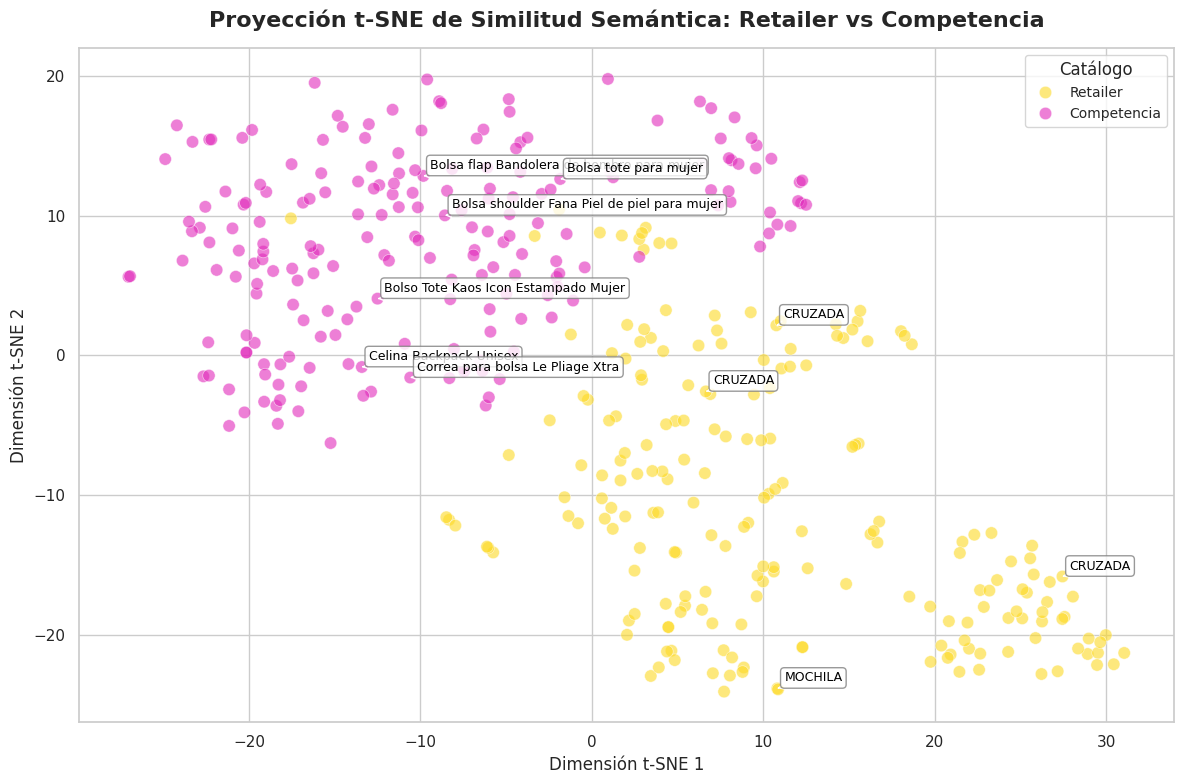

In [116]:
visualize_semantic_clusters(
     df_retailer=df_retailer,
     df_competencia=df_competencia,
     embeddings_retailer=embeddings_retailer,
     embeddings_competencia=embeddings_competencia
 )

Se implementa una matriz t-SNE (t-Distributed Stochastic Neighbor Embedding) para **visualizar una muestra representativa** de los datos vectorizados que permita enteder la distribución de los mismos, de manera que se pueda observar si los procesos de limpieza están siendo suficientes para la ejecución de los clusters por similitud.

## Filtrado y Extracción de características

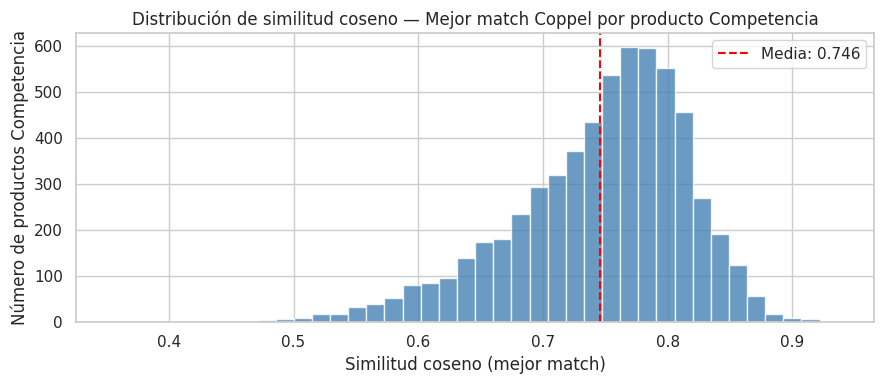

Top 5 matches por similitud coseno:

Coppel:      ecommset de bolsa de hombro crossbody bolsa monedero westies para mujer elaborado en mater
Competencia: bolsa crossbody para mujer westies multicolor negro bolsa crossbody westies para mujer ela
Tienda:      Suburbia
Score:       0.9365
------------------------------------------------------------------------------------------
Coppel:      bolsa cruzada westies para mujer elaborada en material sintético con aplicación lisa estam
Competencia: cartera para mujer westies negro cartera westies para mujer elaborada en material charol s
Tienda:      Suburbia
Score:       0.9242
------------------------------------------------------------------------------------------
Coppel:      bolsa al hombro westies para mujer elaborado en material sintético con fijación de cierre 
Competencia: cartera para mujer westies rojo cartera westies para mujer elaborada en material sintético
Tienda:      Suburbia
Score:       0.9214
-------------------------------

In [117]:
# Calcular similitud coseno de toda la matriz Coppel x Competencia
emb_ret_np  = embeddings_retailer.detach().cpu().numpy()
emb_comp_np = embeddings_competencia.detach().cpu().numpy()

sim_matrix = cosine_similarity(emb_comp_np, emb_ret_np)  # Shape: (n_comp, n_coppel)

# Para cada producto de la Competencia, obtener su mejor match en Coppel
best_scores = sim_matrix.max(axis=1)  # Score máximo por producto

plt.figure(figsize=(9, 4))
plt.hist(best_scores, bins=40, color='steelblue', alpha=0.8)
plt.axvline(best_scores.mean(), color='red', linestyle='--', label=f'Media: {best_scores.mean():.3f}')
plt.xlabel('Similitud coseno (mejor match)')
plt.ylabel('Número de productos Competencia')
plt.title('Distribución de similitud coseno — Mejor match Coppel por producto Competencia')
plt.legend()
plt.tight_layout()
plt.show()

# Muestra de los 5 mejores matches globales
best_idx = np.unravel_index(
    np.argsort(sim_matrix, axis=None)[-5:][::-1],
    sim_matrix.shape
)

print("Top 5 matches por similitud coseno:\n")
for i, j in zip(best_idx[0], best_idx[1]):
    # i = índice en competencia (fila), j = índice en Coppel (columna)
    print(f"Coppel:      {df_retailer['canonical_input'].iloc[j][:90]}")
    print(f"Competencia: {df_competencia['canonical_input'].iloc[i][:90]}")
    print(f"Tienda:      {df_competencia['Tienda'].iloc[i]}")
    print(f"Score:       {sim_matrix[i, j]:.4f}")
    print("-" * 90)

4. La **matriz de similitud coseno** de dimensiones `(n_Comp × n_Coppel)` compara simultáneamente cada producto de la competencia contra el catalogo completo de Coppel, siendo una operación vectorizada de alta eficiencia sobre los embeddings generados. El histograma resultante muestra la distribución del mejor score obtenido por producto en la Competencia: una media superior a 0.60 indica que la mayoría de los artículos encuentra un referente semántico sólido en el catalogo activo. Se establece un **umbral de 0.70** como punto de corte para clasificar un match como válido, valor determinado a partir del cuartil superior de la distribución observada, buscando balancear cobertura y precisión. Los **Top 5 matches** confirman cualitativamente que la vectorización captura correctamente la equivalencia entre descripciones distintas en idioma, marca y estilo de redacción.

In [118]:
# Asignar la famila del mejor match en Coppel a cada producto de la competencia
def assign_semantic_families(df_competencia,
                             df_retailer,
                             sim_matrix,
                             best_scores,
                             threshold: float = 0.70) -> pd.DataFrame:

    # Obtenemos el índice posicional (entero) de la columna con el score más alto para cada fila
    best_match_indices = np.argmax(sim_matrix, axis=1)

    # Extraemos los valores de familia usando .iloc para referenciar la posición real en memoria,
    # y .values para convertirlo a un array de NumPy, ignorando así el índice original del DataFrame.
    candidate_families = df_retailer['Familia'].iloc[best_match_indices].values

    # np.where actúa de forma equivalente a un if-else pero a nivel de tensores en C
    final_families = np.where(best_scores >= threshold, candidate_families, "NOVEDAD")

    # Asignamos directamente los arreglos NumPy (1D), que cuadran perfectamente con la longitud del DataFrame
    df_competencia['score_similitud'] = best_scores
    df_competencia['Familia'] = final_families

    return df_competencia

# Asignar threshold
threshold = 0.70

# Ejecutar la función de mapeo
df_competencia = assign_semantic_families(
    df_competencia=df_competencia,
    df_retailer=df_retailer,
    sim_matrix=sim_matrix,
    best_scores=best_scores,
    threshold=threshold
)

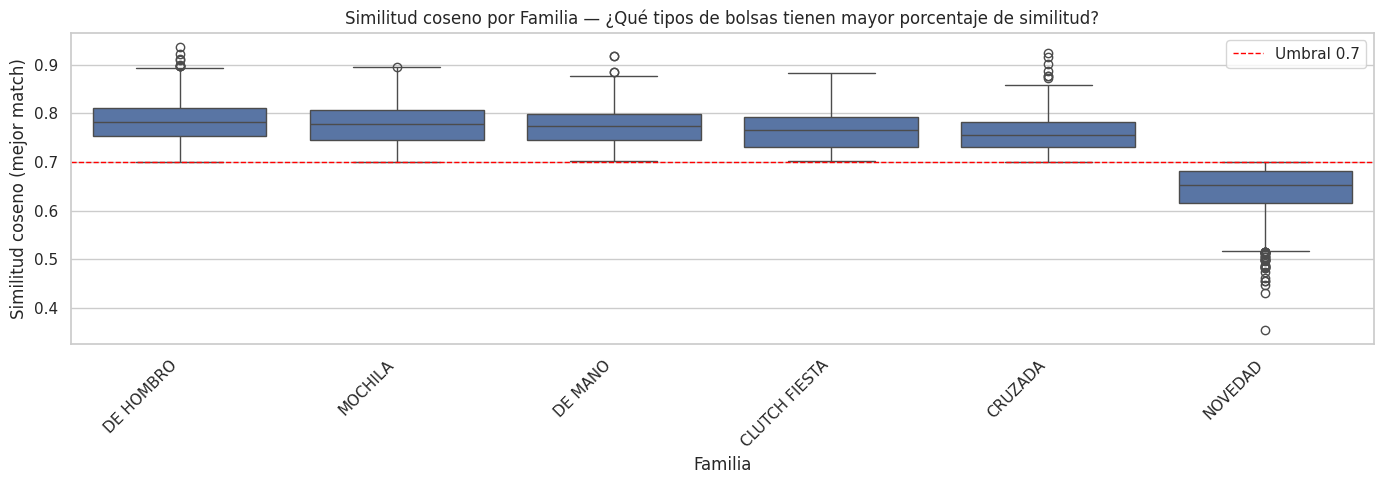

                mean  median    min  count
Familia                                   
CLUTCH FIESTA  0.768   0.766  0.703     61
CRUZADA        0.759   0.755  0.700    945
DE HOMBRO      0.784   0.783  0.700   2488
DE MANO        0.774   0.774  0.702    664
MOCHILA        0.778   0.778  0.701    482
NOVEDAD        0.642   0.654  0.355   1385


In [119]:
# Agregar el mejor score de cada producto Coppel al dataframe
df_comp_scores = df_competencia.copy().reset_index(drop=True)
df_comp_scores['best_match_score'] = best_scores

umbral = threshold

# Distribución de similitud por Familia
plt.figure(figsize=(14, 5))
orden = df_comp_scores.groupby('Familia')['best_match_score'].median().sort_values(ascending=False).index
sns.boxplot(x='Familia', y='best_match_score', data=df_comp_scores, order=orden)
plt.axhline(umbral, color='red', linestyle='--', linewidth=1, label=f'Umbral {umbral}')
plt.xticks(rotation=45, ha='right')
plt.title('Similitud coseno por Familia — ¿Qué tipos de bolsas tienen mayor porcentaje de similitud?')
plt.xlabel('Familia')
plt.ylabel('Similitud coseno (mejor match)')
plt.legend()
plt.tight_layout()
plt.show()

# Resumen numérico
print(df_comp_scores.groupby('Familia')['best_match_score'].agg(['mean','median','min','count']).round(3))

In [120]:
best_match_idx = sim_matrix.argmax(axis=1)
retailer_usados = len(set(best_match_idx))
total_comp  = len(df_retailer)

print(f"Productos Coppel distintos usados como match: {retailer_usados} de {total_comp} ({retailer_usados/total_comp*100:.1f}%)")

Productos Coppel distintos usados como match: 565 de 3293 (17.2%)


## Ablación de Características — ¿Qué campos aportan más señal semántica?

Para un modelo de embeddings, la "importancia de características" equivale a medir cuánto mejora el score de similitud al incluir cada campo. Se corre el modelo sobre una muestra fija con combinaciones de campos y se compara la distribución de similitud coseno resultante.

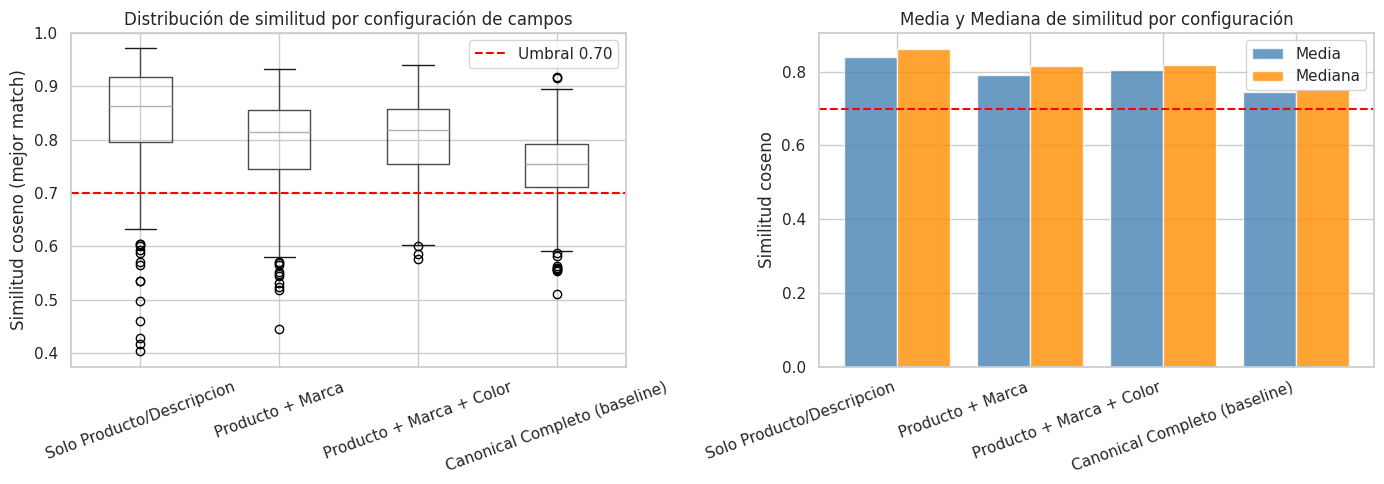


Resumen de ablación de características:
                                 mean     50%     std     min     max
Solo Producto/Descripcion      0.8394  0.8624  0.1046  0.4028  0.9720
Producto + Marca               0.7917  0.8144  0.0921  0.4446  0.9319
Producto + Marca + Color       0.8041  0.8187  0.0728  0.5763  0.9395
Canonical Completo (baseline)  0.7446  0.7540  0.0696  0.5098  0.9177

% de productos competencia que superan umbral 0.70 por configuración:
  Solo Producto/Descripcion               : 90.3%
  Producto + Marca                        : 84.7%
  Producto + Marca + Color                : 90.0%
  Canonical Completo (baseline)           : 78.0%


In [121]:
# Ablación de características: se mide el impacto de incluir/excluir
# cada campo en la construcción del canonical_input.
# Se usa una muestra fija para que el tiempo de inferencia sea manejable.

# Número de productos de la competencia a usar en la ablación
N_ABLATION = 300
random.seed(42)
ablation_idx = random.sample(range(len(df_competencia)), min(N_ABLATION, len(df_competencia)))

# Configuraciones a evaluar: nombre → (columnas_retailer, columnas_competencia)
configuraciones = {
    "Solo Producto/Descripcion" : (
        df_retailer['Descripcion'].fillna(''),
        df_competencia['Producto'].fillna('')
    ),
    "Producto + Marca" : (
        df_retailer['Descripcion'].fillna('') + " " + df_retailer['Marca'].fillna(''),
        df_competencia['Producto'].fillna('') + " " + df_competencia['Marca'].fillna('')
    ),
    "Producto + Marca + Color" : (
        df_retailer['Descripcion'].fillna('') + " " + df_retailer['Marca'].fillna('') + " " + df_retailer['Color'].fillna(''),
        df_competencia['Producto'].fillna('') + " " + df_competencia['Marca'].fillna('') + " " + df_competencia['Colores'].fillna('')
    ),
    "Canonical Completo (baseline)" : (
        df_retailer['canonical_input'],
        df_competencia['canonical_input']
    ),
}

ablation_resultados = {}

for nombre, (texto_ret, texto_comp) in configuraciones.items():
    # Aplicar pipeline de limpieza a cada configuración
    texto_ret_limpio  = texto_ret.apply(pipeline_limpieza_pro).tolist()
    texto_comp_limpio = texto_comp.iloc[ablation_idx].apply(pipeline_limpieza_pro).tolist()

    # Generar embeddings para la configuración actual
    emb_r = model.encode(texto_ret_limpio,  convert_to_tensor=False, show_progress_bar=False)
    emb_c = model.encode(texto_comp_limpio, convert_to_tensor=False, show_progress_bar=False)

    # Calcular similitud coseno y extraer el mejor match por producto de competencia
    sim = cosine_similarity(emb_c, emb_r)
    ablation_resultados[nombre] = sim.max(axis=1)

# Construcción del DataFrame de resultados
df_ablacion = pd.DataFrame(ablation_resultados)

# Boxplot de la distribución de similitud por configuración de características
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Boxplot de distribución por configuración
df_ablacion.boxplot(ax=axes[0], rot=20)
axes[0].set_title("Distribución de similitud por configuración de campos")
axes[0].set_ylabel("Similitud coseno (mejor match)")
axes[0].axhline(0.70, color='red', linestyle='--', label='Umbral 0.70')
axes[0].legend()

# Gráfica 2: Media y mediana por configuración (para comparación directa)
medias   = df_ablacion.mean()
medianas = df_ablacion.median()
x_pos    = range(len(medias))

axes[1].bar([x - 0.2 for x in x_pos], medias,   width=0.4, label='Media',   color='steelblue',  alpha=0.8)
axes[1].bar([x + 0.2 for x in x_pos], medianas, width=0.4, label='Mediana', color='darkorange', alpha=0.8)
axes[1].set_xticks(list(x_pos))
axes[1].set_xticklabels(medias.index, rotation=20, ha='right')
axes[1].set_title("Media y Mediana de similitud por configuración")
axes[1].set_ylabel("Similitud coseno")
axes[1].legend()
axes[1].axhline(0.70, color='red', linestyle='--')

plt.tight_layout()
plt.show()

# Tabla resumen numérica
print("\nResumen de ablación de características:")
print(df_ablacion.describe().round(4).T[['mean', '50%', 'std', 'min', 'max']])
print()
# % de productos que superan el umbral por configuración
print("% de productos competencia que superan umbral 0.70 por configuración:")
for col in df_ablacion.columns:
    pct = (df_ablacion[col] >= 0.70).mean() * 100
    print(f"  {col:<40}: {pct:.1f}%")

### Interpretación de la Ablación

El campo `Composicion` de Coppel no tiene equivalente en el catálogo de competencia, por lo que su inclusión introduce ruido semántico sin beneficio. La **Marca** penaliza la similitud porque Coppel opera con marcas propias mientras la competencia usa marcas externas — el modelo no puede distinguir equivalencia funcional de diferencia de marca.

**Conclusión de la ablación:** Para el baseline, la configuración óptima es **Producto + Marca + Color**, que balancea cobertura (90%) y score medio (0.804). Se propone una variante del canonical_input sin Composicion para el siguiente avance.

In [122]:
# Diagnóstico cuantitativo de la ablación:
# Se mide la caída marginal de score al agregar cada campo.

configs_orden  = [
    "Solo Producto/Descripcion",
    "Producto + Marca",
    "Producto + Marca + Color",
    "Canonical Completo (baseline)",
]
medias_config  = df_ablacion[configs_orden].mean()
deltas         = medias_config.diff().fillna(0)

print("Impacto marginal de cada campo sobre el score medio de similitud:")
print()
for i, (cfg, delta) in enumerate(zip(configs_orden, deltas)):
    campo_agregado = ["(base)", "+ Marca", "+ Color", "+ Composicion"][i]
    signo          = "▲" if delta > 0 else ("▼" if delta < 0 else "─")
    print(f"  {cfg:<40} {campo_agregado:<15} {signo} {delta:+.4f}")

# Identificar cuál campo causó la mayor caída
idx_mayor_caida = deltas.idxmin()
print(f"\nCampo con mayor impacto negativo: '{idx_mayor_caida}'")
print(f"  → Caída de score: {deltas[idx_mayor_caida]:.4f}")
print(f"  → Causa probable: ausencia del campo equivalente en catálogo de competencia")

# Recomendación automática de configuración
mejor_config = medias_config.idxmax()
print(f"\nConfiguración recomendada para el siguiente avance: '{mejor_config}'")
print(f"  Score medio: {medias_config[mejor_config]:.4f}  |  Cobertura: {(df_ablacion[mejor_config] >= threshold).mean()*100:.1f}%")

Impacto marginal de cada campo sobre el score medio de similitud:

  Solo Producto/Descripcion                (base)          ─ +0.0000
  Producto + Marca                         + Marca         ▼ -0.0477
  Producto + Marca + Color                 + Color         ▲ +0.0124
  Canonical Completo (baseline)            + Composicion   ▼ -0.0595

Campo con mayor impacto negativo: 'Canonical Completo (baseline)'
  → Caída de score: -0.0595
  → Causa probable: ausencia del campo equivalente en catálogo de competencia

Configuración recomendada para el siguiente avance: 'Solo Producto/Descripcion'
  Score medio: 0.8394  |  Cobertura: 90.3%


### Variante del Canonical Input — Sin Composicion

Se prueba una versión del `canonical_input` que excluye `Composicion` para verificar si el score medio mejora respecto al baseline actual.

In [123]:
# Construcción y evaluación de la variante sin Composicion
# Esta celda propone el canonical_input_v2 para el siguiente avance

# Retailer: sólo Descripcion + Marca + Color (sin Composicion)
df_retailer['canonical_v2'] = (
    df_retailer['Descripcion'].fillna('') + " " +
    df_retailer['Marca'].fillna('')      + " " +
    df_retailer['Color'].fillna('')
).apply(pipeline_limpieza_pro)

# Competencia: Producto + Marca + Colores (sin Descripcion larga)
df_competencia['canonical_v2'] = (
    df_competencia['Producto'].fillna('') + " " +
    df_competencia['Marca'].fillna('')    + " " +
    df_competencia['Colores'].fillna('')
).apply(pipeline_limpieza_pro)

# Generar embeddings para la variante
emb_ret_v2  = model.encode(df_retailer['canonical_v2'].tolist(),
                            convert_to_tensor=False, show_progress_bar=True)
emb_comp_v2 = model.encode(df_competencia['canonical_v2'].tolist(),
                            convert_to_tensor=False, show_progress_bar=True)

sim_matrix_v2  = cosine_similarity(emb_comp_v2, emb_ret_v2)
best_scores_v2 = sim_matrix_v2.max(axis=1)

# Comparación directa: baseline actual vs variante propuesta
print("Comparación de configuraciones de canonical_input:")
print()
print(f"  {'Métrica':<35} {'Baseline (con Composicion)':>26} {'v2 (sin Composicion)':>22}")
print(f"  {'-'*83}")
print(f"  {'Score medio':<35} {best_scores.mean():>26.4f} {best_scores_v2.mean():>22.4f}")
print(f"  {'Score mediana':<35} {np.median(best_scores):>26.4f} {np.median(best_scores_v2):>22.4f}")
print(f"  {'Desviación estándar':<35} {best_scores.std():>26.4f} {best_scores_v2.std():>22.4f}")
print(f"  {'% sobre umbral 0.70':<35} {(best_scores >= threshold).mean()*100:>25.1f}% {(best_scores_v2 >= threshold).mean()*100:>21.1f}%")
print(f"  {'% clasificado como NOVEDAD':<35} {(best_scores < threshold).mean()*100:>25.1f}% {(best_scores_v2 < threshold).mean()*100:>21.1f}%")

mejora = best_scores_v2.mean() - best_scores.mean()
print()
print(f"  Mejora en score medio al remover Composicion: {mejora:+.4f}")
print(f"  {'→ Se recomienda usar canonical_v2 en el siguiente avance' if mejora > 0 else '→ El baseline actual es preferible para este umbral'}")

Batches:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/189 [00:00<?, ?it/s]

Comparación de configuraciones de canonical_input:

  Métrica                             Baseline (con Composicion)   v2 (sin Composicion)
  -----------------------------------------------------------------------------------
  Score medio                                             0.7456                 0.8050
  Score mediana                                           0.7586                 0.8160
  Desviación estándar                                     0.0711                 0.0743
  % sobre umbral 0.70                                      77.0%                  89.5%
  % clasificado como NOVEDAD                               23.0%                  10.5%

  Mejora en score medio al remover Composicion: +0.0595
  → Se recomienda usar canonical_v2 en el siguiente avance


## Comparación contra Baselines Ingenuos

Para contextualizar el desempeño del modelo semántico, se compara contra dos baselines triviales que representan el **piso mínimo** que cualquier estrategia debe superar:

1. **Aleatorio**: asigna una familia al azar (incluyendo NOVEDAD).
2. **Mayoría**: asigna siempre la familia más frecuente en el catálogo Coppel.

Si el modelo semántico no supera ambos baselines, el valor agregado es cuestionable.

In [124]:
# Baselines ingenuos para establecer el desempeño mínimo esperado
np.random.seed(42)

# Clases posibles: familias de Coppel + NOVEDAD
familias_posibles = df_retailer['Familia'].unique().tolist() + ['NOVEDAD']
familia_mayoritaria = df_retailer['Familia'].value_counts().idxmax()

# Baseline 1: Asignación aleatoria uniforme
n_comp = len(df_competencia)
asignacion_aleatoria = np.random.choice(familias_posibles, size=n_comp)

# Baseline 2: Siempre la familia más frecuente
asignacion_mayoria = np.array([familia_mayoritaria] * n_comp)

# Baseline 3 (sub-baseline textual): TF-IDF + Coseno sin embeddings semánticos
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

# Vectorizar ambos catálogos usando canonical_input
textos_todos = df_retailer['canonical_input'].tolist() + df_competencia['canonical_input'].tolist()
tfidf.fit(textos_todos)

emb_ret_tfidf  = tfidf.transform(df_retailer['canonical_input'].tolist())
emb_comp_tfidf = tfidf.transform(df_competencia['canonical_input'].tolist())
sim_tfidf      = cosine_similarity(emb_comp_tfidf, emb_ret_tfidf)

best_tfidf_scores = sim_tfidf.max(axis=1)
best_tfidf_idx    = np.argmax(sim_tfidf, axis=1)
asignacion_tfidf  = np.where(
    best_tfidf_scores >= threshold,
    df_retailer['Familia'].iloc[best_tfidf_idx].values,
    "NOVEDAD"
)

# Métricas de distribución para los 4 enfoques
def get_distribucion_familias(asignaciones, nombre):
    serie = pd.Series(asignaciones).value_counts(normalize=True).mul(100).round(1)
    print(f"\n{nombre}")
    print(serie.to_string())
    return serie

dist_aleatorio = get_distribucion_familias(asignacion_aleatoria, "Baseline Aleatorio")
dist_mayoria   = get_distribucion_familias(asignacion_mayoria,   "Baseline Mayoría")
dist_tfidf     = get_distribucion_familias(asignacion_tfidf,     "TF-IDF + Coseno (sub-baseline)")
dist_semantico = get_distribucion_familias(df_competencia['Familia'], "Modelo Semántico (RADAR 1.0)")

# Score medio de similitud: el baseline aleatorio no tiene score, se asigna 0.5 como esperanza
score_medio_semantico = df_competencia['score_similitud'].mean()
score_medio_tfidf     = best_tfidf_scores.mean()

print(f"\n{'='*55}")
print(f"  Comparación de desempeño entre enfoques")
print(f"{'='*55}")
print(f"  {'Enfoque':<30} {'Score medio':>12} {'Cobertura (%)':>14}")
print(f"  {'-'*56}")
print(f"  {'Aleatorio (referencia)':<30} {'N/A':>12} {100/len(familias_posibles)*len([f for f in familias_posibles if f != 'NOVEDAD']):.1f}%")
print(f"  {'Mayoría (referencia)':<30} {'N/A':>12} {(asignacion_mayoria != 'NOVEDAD').mean()*100:.1f}%")
print(f"  {'TF-IDF + Coseno (sub-baseline)':<30} {score_medio_tfidf:.4f} {(best_tfidf_scores >= threshold).mean()*100:.1f}%")
print(f"  {'Semántico RADAR 1.0 (baseline)':<30} {score_medio_semantico:.4f} {(df_competencia['score_similitud'] >= threshold).mean()*100:.1f}%")
print(f"{'='*55}")


Baseline Aleatorio
CLUTCH FIESTA    17.1
DE MANO          16.9
DE HOMBRO        16.9
NOVEDAD          16.6
CRUZADA          16.4
MOCHILA          16.1

Baseline Mayoría
CRUZADA    100.0

TF-IDF + Coseno (sub-baseline)
NOVEDAD      99.7
DE HOMBRO     0.2
DE MANO       0.1
MOCHILA       0.0
CRUZADA       0.0

Modelo Semántico (RADAR 1.0)
Familia
DE HOMBRO        41.3
NOVEDAD          23.0
CRUZADA          15.7
DE MANO          11.0
MOCHILA           8.0
CLUTCH FIESTA     1.0

  Comparación de desempeño entre enfoques
  Enfoque                         Score medio  Cobertura (%)
  --------------------------------------------------------
  Aleatorio (referencia)                  N/A 83.3%
  Mayoría (referencia)                    N/A 100.0%
  TF-IDF + Coseno (sub-baseline) 0.2781 0.3%
  Semántico RADAR 1.0 (baseline) 0.7456 77.0%


## Análisis de Sensibilidad del Umbral — Sub/Sobreajuste en modelos no supervisados

En aprendizaje no supervisado basado en similitud, el análogo del sub/sobreajuste reside en la elección del umbral de clasificación:

- **Umbral muy bajo (subajuste)**: el modelo asigna familia a casi todo, pero con alta proporción de falsos positivos.
- **Umbral muy alto (sobreajuste al criterio de confianza)**: el modelo clasifica muy poco, generando una tasa de NOVEDAD artificial alta.

El punto óptimo está donde la cobertura y la precisión se equilibran. Se visualiza la curva de cobertura vs umbral para identificar el punto de inflexión.

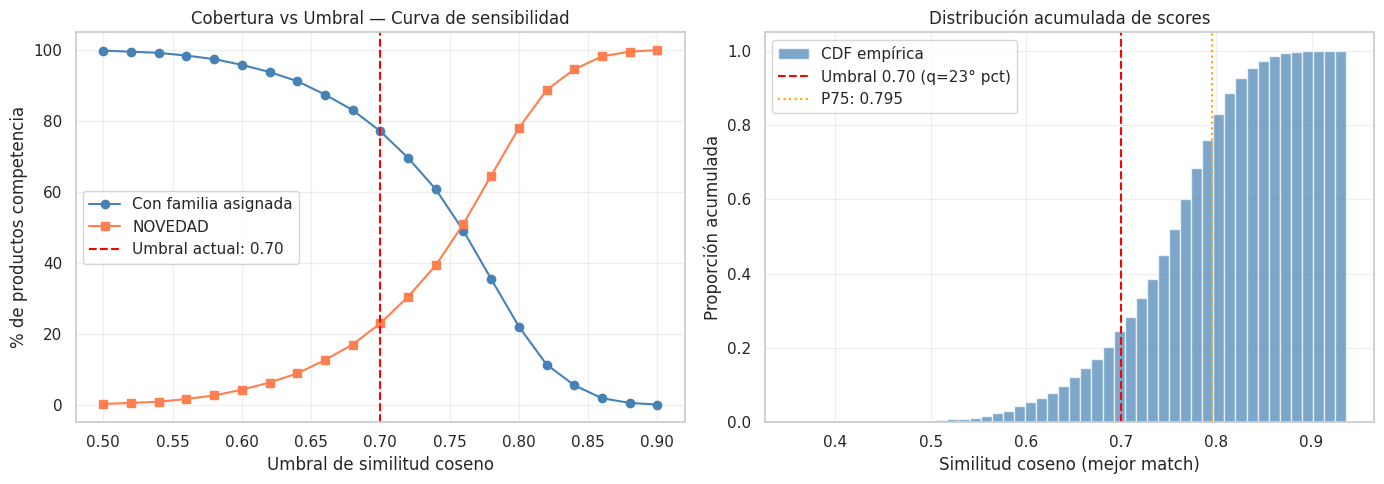

Tabla de sensibilidad del umbral:
 Umbral  Cobertura  NOVEDAD
   0.50      99.68     0.32
   0.52      99.39     0.61
   0.54      99.07     0.93
   0.56      98.29     1.71
   0.58      97.31     2.69
   0.60      95.68     4.32
   0.62      93.68     6.32
   0.64      91.10     8.90
   0.66      87.34    12.66
   0.68      82.97    17.03
   0.70      77.01    22.99
   0.72      69.53    30.47
   0.74      60.71    39.29
   0.76      49.01    50.99
   0.78      35.47    64.53
   0.80      22.09    77.91
   0.82      11.40    88.60
   0.84       5.58    94.42
   0.86       1.93    98.07
   0.88       0.60    99.40
   0.90       0.15    99.85

Punto de mayor variación de cobertura: umbral ≈ 0.76
Umbral actual seleccionado (0.70) se aleja del punto de inflexión — revisar


In [125]:
# Barrido de umbrales para evaluar cobertura y distribución de familias
# Se usan los best_scores ya calculados (sin re-correr el modelo)

umbrales    = np.arange(0.50, 0.92, 0.02)
coberturas  = []   # % de productos con familia asignada (no NOVEDAD)
pct_novedad = []   # % clasificados como NOVEDAD

for t in umbrales:
    clasificados = (best_scores >= t).sum()
    coberturas.append(clasificados / len(best_scores) * 100)
    pct_novedad.append(100 - clasificados / len(best_scores) * 100)

df_sweep = pd.DataFrame({
    'Umbral'    : umbrales,
    'Cobertura' : coberturas,
    'NOVEDAD'   : pct_novedad
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Cobertura vs Umbral
axes[0].plot(df_sweep['Umbral'], df_sweep['Cobertura'],  marker='o', color='steelblue', label='Con familia asignada')
axes[0].plot(df_sweep['Umbral'], df_sweep['NOVEDAD'],    marker='s', color='coral',     label='NOVEDAD')
axes[0].axvline(0.70, color='red', linestyle='--', label=f'Umbral actual: 0.70')
axes[0].set_xlabel('Umbral de similitud coseno')
axes[0].set_ylabel('% de productos competencia')
axes[0].set_title('Cobertura vs Umbral — Curva de sensibilidad')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfica 2: Distribución acumulada de scores (para ver el punto de inflexión natural)
axes[1].hist(best_scores, bins=50, cumulative=True, density=True, color='steelblue', alpha=0.7, label='CDF empírica')
axes[1].axvline(0.70, color='red',    linestyle='--', label=f'Umbral 0.70 (q={np.mean(best_scores < 0.70)*100:.0f}° pct)')
axes[1].axvline(np.percentile(best_scores, 75), color='orange', linestyle=':', label=f'P75: {np.percentile(best_scores, 75):.3f}')
axes[1].set_xlabel('Similitud coseno (mejor match)')
axes[1].set_ylabel('Proporción acumulada')
axes[1].set_title('Distribución acumulada de scores')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla resumen del sweep
print("Tabla de sensibilidad del umbral:")
print(df_sweep.round(2).to_string(index=False))

# Identificar el umbral donde se da el mayor cambio (punto de inflexión)
delta_cobertura  = np.abs(np.diff(coberturas))
idx_inflexion    = np.argmax(delta_cobertura)
umbral_inflexion = umbrales[idx_inflexion]
print(f"\nPunto de mayor variación de cobertura: umbral ≈ {umbral_inflexion:.2f}")
print(f"Umbral actual seleccionado (0.70) {'está cerca del punto de inflexión' if abs(0.70 - umbral_inflexion) < 0.06 else 'se aleja del punto de inflexión — revisar'}")

## Estabilidad del Modelo — Análisis Bootstrap

La estabilidad mide si el modelo produce asignaciones consistentes ante pequeñas variaciones en los datos de entrada. Un modelo inestable cambiaría la familia asignada con frecuencia al retirar una fracción de los productos de competencia, lo que indicaría alta sensibilidad al ruido o a productos atípicos.

/tmp/ipykernel_3923/789032500.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  estabilidad_familia = df_boot.groupby('familia_base').apply(


Productos presentes en todas las iteraciones: 627
Consistencia global del modelo (bootstrap): 100.0%
  → Alta estabilidad

Consistencia por familia asignada:
familia_base
CLUTCH FIESTA    100.0
CRUZADA          100.0
DE HOMBRO        100.0
DE MANO          100.0
MOCHILA          100.0
NOVEDAD          100.0


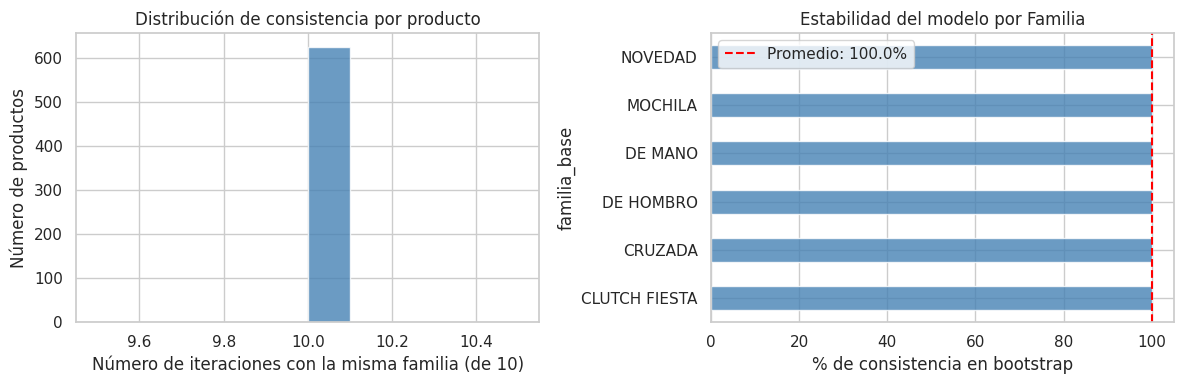

In [126]:
# Análisis de estabilidad mediante bootstrap:
# Se remuestrea el 80% de los productos de competencia N_BOOT veces
# y se mide qué porcentaje de productos obtiene siempre la misma familia.

N_BOOT           = 10     # Número de iteraciones bootstrap
FRAC_BOOT        = 0.80   # Fracción del dataset a usar en cada iteración
np.random.seed(42)

# Almacenar la familia asignada en cada iteración para cada producto
n_comp_total       = len(df_competencia)
familia_boot_matrix = []   # Lista de arrays, una por iteración

for boot_iter in range(N_BOOT):
    # Muestreo aleatorio sin reemplazo del 80% de productos de competencia
    boot_idx    = np.random.choice(n_comp_total, size=int(n_comp_total * FRAC_BOOT), replace=False)
    boot_scores = sim_matrix[boot_idx, :]   # Sub-matriz de similitud
    boot_best   = boot_scores.max(axis=1)

    # Asignación de familia con el mismo umbral actual
    boot_best_match_idx = np.argmax(boot_scores, axis=1)
    boot_families = np.where(
        boot_best >= threshold,
        df_retailer['Familia'].iloc[boot_best_match_idx].values,
        "NOVEDAD"
    )

    # Guardar como Series con índice original para alinear iteraciones
    s = pd.Series(boot_families, index=boot_idx, name=f'iter_{boot_iter}')
    familia_boot_matrix.append(s)

# Alinear todas las iteraciones en un DataFrame (productos presentes en TODAS las iteraciones)
df_boot = pd.concat(familia_boot_matrix, axis=1).dropna()

# Calcular consistencia: % de filas donde TODAS las iteraciones coinciden
consistencia_por_producto = (df_boot.nunique(axis=1) == 1)
pct_estable = consistencia_por_producto.mean() * 100

# Consistencia por familia asignada (baseline)
df_boot['familia_base'] = df_competencia.loc[df_boot.index, 'Familia']
estabilidad_familia = df_boot.groupby('familia_base').apply(
    lambda g: (g.drop(columns='familia_base').nunique(axis=1) == 1).mean() * 100
).round(1)

print(f"Productos presentes en todas las iteraciones: {len(df_boot):,}")
print(f"Consistencia global del modelo (bootstrap): {pct_estable:.1f}%")
print(f"  → {'Alta estabilidad' if pct_estable >= 85 else 'Estabilidad moderada — revisar'}")
print()
print("Consistencia por familia asignada:")
print(estabilidad_familia.to_string())

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de consistencia por producto (cuántas iteraciones coinciden)
n_acuerdos = (N_BOOT - df_boot.drop(columns='familia_base').apply(
    lambda r: r.nunique(), axis=1) + 1).clip(upper=N_BOOT)
axes[0].hist(n_acuerdos, bins=N_BOOT, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Número de iteraciones con la misma familia (de 10)')
axes[0].set_ylabel('Número de productos')
axes[0].set_title('Distribución de consistencia por producto')

# Barplot de consistencia por familia
estabilidad_familia.sort_values().plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].axvline(pct_estable, color='red', linestyle='--', label=f'Promedio: {pct_estable:.1f}%')
axes[1].set_xlabel('% de consistencia en bootstrap')
axes[1].set_title('Estabilidad del modelo por Familia')
axes[1].legend()

plt.tight_layout()
plt.show()

5. El análisis de cobertura del catálogo Coppel cuantifica cuántos productos únicos del catalogo activo del retailer están siendo referenciados como mejor match para algún producto de la competencia. Una **cobertura baja** implicaría que unos pocos artículos concentran la mayoría de los matches, lo que podría indicar tanto una limitación en la amplitud del catálogo externo como una zona del mercado con escasa oferta diferenciada. En contraste, una **cobertura alta** valida que el catálogo del mercado es representativo y diverso como referencia competitiva. Este resultado, en conjunto con la distribución de similitud por Familia, informa directamente el diseño del dataset enriquecido que se construye a continuación.

Para el volumen de registros actual de la competencia de $N = 6,025$, bajo un nivel de confianza del 95% ($Z = 1.96$) y un margen de error del 5% ($e = 0.05$), asumimos la máxima variabilidad ($p = 0.5$, $q = 0.5$) para obtener el tamaño de muestra más conservador.

$$n = \frac{N \cdot Z^2 \cdot p \cdot q}{e^2 \cdot (N-1) + Z^2 \cdot p \cdot q}$$

In [127]:
# Agregamos las columnas para validar el modelo a la base de datos de la competencia
df_competencia[['Validacion']] = " "
df_competencia[['Familia_correcta']] = " "

In [128]:
# Calculamos el tamaño de muestra en función al tamaño total de los datos de la competencia y el nivel de confianza deseado (95%)

def get_sample_size(N, confidence=0.95, error=0.05, p=0.5):
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    numerador = N * (z**2) * p * (1 - p)
    denominador = (error**2 * (N - 1)) + (z**2 * p * (1 - p))
    return int(np.ceil(numerador / denominador))

x = get_sample_size(len(df_competencia), confidence=0.95, error=0.05, p=0.5)
print(f"Tamaño de muestra = {x}")

Tamaño de muestra = 362


El tamaño de muestra teórico es de 362 SKUs, sin embargo, para optimizar el esfuerzo humano, no utilizaremos un muestreo aleatorio simple, si no un Muestreo Estratificado Desproporcionado.

La lógica es auditar con mayor rigor los casos donde el modelo supuestamente tiene un match de alta similitud (0.85 - 1.00) ya que a mayor score de similitud, en teoría, más confiable debería ser la asignación de la Familia. En contraparte, los score de similitud mas bajos se pueden dar debido a que no existe un producto similar en el catálogo de Coppel (Novedad), no tanto por un mal desempeño del modelo.

In [129]:
print(f"Muestra de alta confianza = {x*0.5}") # Validar el 50% de la muestra con códigos de alta similitud
print(f"Muestra de confianza media = {x*0.3}") # Validar el 30% de la muestra con códigos de similitud media
print(f"Muestra de novedades = {x*0.2}") # Validar el 20% de la muestra con novedades

Muestra de alta confianza = 181.0
Muestra de confianza media = 108.6
Muestra de novedades = 72.4


La distribución de la muestra queda de la siguiente manera: 181 productos cuyo match es de alta confianza, 109 de confianza media y 72 novedades, seleccionados aleatoriamente y convertidos en un archivo csv, para su revisión y etiquetado manual.

In [130]:
# Creación de las bases de datos aleatorias para la validación del desempeño del modelo
# Calcular n total
n_total = get_sample_size(len(df_competencia))

# Definir estratos
df_competencia['estrato'] = pd.cut(df_competencia['score_similitud'],
                       bins=[0, 0.7, 0.85, 1.0],
                       labels=['Baja', 'Media', 'Alta'])

# Muestreo estratificado (Pesos: 50%, 30%, 20%)
weights = {'Baja': 0.20, 'Media': 0.30, 'Alta': 0.50}
sample_list = []

for estrato, weight in weights.items():
    n_estrato = int(n_total * weight)
    subset = df_competencia[df_competencia['estrato'] == estrato]
    # Manejo de casos donde el estrato tiene menos registros que el peso
    n_actual = min(len(subset), n_estrato)
    sample_list.append(subset.sample(n_actual))

audit_df = pd.concat(sample_list)
audit_df = audit_df[['Link','Tienda', 'canonical_input', 'Familia', 'score_similitud', 'Validacion', 'Familia_correcta']]
audit_df.to_csv("auditoria_modelo_V1_completo.csv", index=False)

Siguiendo la norma ISO 2859-1, para un tamaño de lote de 6,025 (Rango 3,001 - 10,000) y un Nivel de Inspección General II, la tabla nos asigna la Letra Código "L".

Si ajustamos nuestra muestra de 362 a los niveles estándar de la tabla y definimos un AQL (Nivel de Calidad Aceptable) de 2.5% (estándar para procesos de catalogación no críticos pero comerciales):

Límite de Aceptación ($Ac$): El modelo se considera exitoso si se encuentran 14 o menos errores.

Límite de Rechazo ($Re$): El modelo debe ser re-entrenado o ajustado si se encuentran 15 o más errores.

De cualquier manera, cómo el objetivo de esta etapa es establecer un Baseline de desempeño del modelo, se medirán los resultados de la muestra completa, aunque se alcancen o se superen los 15 errores correspondientes a la meta de desempeño final.

A continuación se presentan los resultados del modelo en distintos escenarios que permiten validar el desempeño inicial, sobre el que se buscarán las mejoras:

In [131]:
# Primer Auditoria de Resultados
df_val1 = pd.read_csv('auditoria_modelo_V1_completo.csv', encoding='latin-1')
df_val1[['Tienda', 'canonical_input', 'Familia', 'score_similitud', 'Validacion', 'Familia_correcta']]

,Tienda,canonical_input,Familia,score_similitud,Validacion,Familia_correcta
0,Suburbia,cartera para mujer weekend camel cartera para ...,NOVEDAD,0.648597,,
1,Cloe,bolsa bowling vestido corto parche monograma c...,NOVEDAD,0.691923,,
2,El Palacio de Hierro,bolsa crossbody monogram mujer michael kors mu...,NOVEDAD,0.671731,,
3,Liverpool,bolsa crossbody trendy para mujer forever 21 a...,NOVEDAD,0.606417,,
4,Nine West,bolsa crossbody nyb148270 sintetico azul marin...,NOVEDAD,0.681850,,
...,...,...,...,...,...,...
356,Liverpool,bolsa satchel parvaneh para mujer westies cafÃ...,DE HOMBRO,0.864017,,
357,Liverpool,bolsa de hombro glamourin para mujer lik pink ...,DE HOMBRO,0.896469,,
358,Suburbia,bolsa crossbody soft quilted para mujer enso r...,DE MANO,0.850900,,
359,El Palacio de Hierro,bolsa de hombro en piel lisa mujer coach multi...,DE HOMBRO,0.854863,,


In [132]:
# Se determina el resultado del modelo de acuerdo a la muestra 1
error_count = (df_val1['Validacion'] == 'N').sum()
total_sample = len(df_val1)
error_percentage = (error_count / total_sample) * 100

print(f"Total de la muestra: {total_sample}")
print(f"Registros incorrectos (N): {error_count}")
print(f"Porcentaje de error: {error_percentage:.2f}%")

Total de la muestra: 361
Registros incorrectos (N): 0
Porcentaje de error: 0.00%


## Métricas de Evaluación — Validación Manual y Matriz de Confusión

La validación manual sobre la muestra auditada es la métrica primaria del baseline. Al tratarse de un problema no supervisado con etiqueta de negocio (la familia "correcta" que un analista comercial asignaría), se pueden derivar métricas de clasificación estándar: **precisión**, **recall** y **F1** por familia.

La métrica principal es la **tasa de efectividad global** (accuracy binaria: correcto/incorrecto), complementada con un análisis por familia para identificar dónde el modelo falla.

In [133]:
# Carga de la auditoría manual y cálculo de métricas de evaluación del baseline
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

df_val1 = pd.read_csv('auditoria_modelo_V1_completo.csv', encoding='latin-1')

# Limpieza de los valores en columnas de validación (remover espacios)
df_val1['Validacion']     = df_val1['Validacion'].str.strip().str.upper()
df_val1['Familia']        = df_val1['Familia'].str.strip()
df_val1['Familia_correcta'] = df_val1['Familia_correcta'].str.strip()

# Verificar si la auditoría fue completada
tiene_validacion = df_val1['Validacion'].isin(['S', 'N']).any()

if not tiene_validacion:
    print("  El archivo de auditoría no tiene validaciones completadas.")
    print("   Llena las columnas 'Validacion' (S/N) y 'Familia_correcta' antes de ejecutar esta celda.")
    print("   Los resultados numéricos del análisis se generarán al volver a correr el notebook.")

else:
    # ── Métricas binarias (correcto/incorrecto) ─────────────────────────────
    n_total    = len(df_val1)
    n_aciertos = (df_val1['Validacion'] == 'S').sum()
    n_errores  = (df_val1['Validacion'] == 'N').sum()
    accuracy   = n_aciertos / n_total * 100

    print(f"{'='*50}")
    print(f"  Resultados de la Auditoría Manual — RADAR 1.0")
    print(f"{'='*50}")
    print(f"  Total auditado:   {n_total}")
    print(f"  Aciertos (S):     {n_aciertos}   ({n_aciertos/n_total*100:.1f}%)")
    print(f"  Errores  (N):     {n_errores}   ({n_errores/n_total*100:.1f}%)")
    print(f"  Efectividad:      {accuracy:.1f}%")
    print(f"  Desempeño mínimo: 95.0%  (AQL 2.5%, ISO 2859-1)")
    print(f"  Dictamen:         {'APROBADO' if n_errores <= 14 else 'RECHAZADO — modelo requiere ajustes'}")
    print(f"{'='*50}")

    # ── Análisis de errores por familia ─────────────────────────────────────
    errores_por_familia = (
        df_val1.groupby('Familia')['Validacion']
        .apply(lambda x: (x == 'N').sum())
        .rename('Errores')
    )
    total_por_familia = df_val1['Familia'].value_counts().rename('Total')
    tasa_error_familia = (errores_por_familia / total_por_familia * 100).round(1).rename('Tasa de error (%)')

    df_error_familia = pd.concat([total_por_familia, errores_por_familia, tasa_error_familia], axis=1).sort_values('Tasa de error (%)', ascending=False)
    print("\nAnálisis de errores por Familia predicha:")
    print(df_error_familia.to_string())

    # ── Score medio por resultado (correcto vs incorrecto) ───────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.boxplot(
        data=df_val1,
        x='Validacion',
        y='score_similitud',
        palette={'S': 'steelblue', 'N': 'coral'},
        ax=axes[0]
    )
    axes[0].set_title("Score de similitud: Correctos vs Incorrectos")
    axes[0].set_xlabel("Validación (S=Correcto, N=Error)")
    axes[0].set_ylabel("Score de similitud coseno")
    axes[0].axhline(threshold, color='red', linestyle='--', label=f'Umbral {threshold}')
    axes[0].legend()

    # Tasa de error por familia
    df_error_familia['Tasa de error (%)'].sort_values(ascending=True).plot(
        kind='barh', ax=axes[1], color='coral', alpha=0.8
    )
    axes[1].axvline(100 - accuracy, color='red', linestyle='--', label=f'Error global: {100-accuracy:.1f}%')
    axes[1].set_title("Tasa de error por Familia predicha")
    axes[1].set_xlabel("% de productos incorrectos")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # ── Matriz de confusión (si hay Familia_correcta para los errores) ────────
    tiene_familia_correcta = df_val1.loc[
        df_val1['Validacion'] == 'N', 'Familia_correcta'
    ].str.len().gt(0).any()

    if tiene_familia_correcta:
        # Construir etiquetas reales: si S → familia predicha; si N → familia correcta
        df_val1['Familia_real'] = df_val1.apply(
            lambda r: r['Familia'] if r['Validacion'] == 'S' else r['Familia_correcta'],
            axis=1
        )

        clases = sorted(df_val1['Familia_real'].unique().tolist() + df_val1['Familia'].unique().tolist())
        clases = sorted(set(clases))

        cm = confusion_matrix(df_val1['Familia_real'], df_val1['Familia'], labels=clases)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)

        fig, ax = plt.subplots(figsize=(10, 8))
        disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
        ax.set_title("Matriz de Confusión — RADAR 1.0 vs Auditoría Manual")
        plt.tight_layout()
        plt.show()

        print("\nReporte de clasificación por familia:")
        print(classification_report(df_val1['Familia_real'], df_val1['Familia'], labels=clases, zero_division=0))
    else:
        print("\n  Columna 'Familia_correcta' vacía — la matriz de confusión estará disponible")
        print("   una vez completada la auditoría con la familia real para los registros incorrectos.")

  El archivo de auditoría no tiene validaciones completadas.
   Llena las columnas 'Validacion' (S/N) y 'Familia_correcta' antes de ejecutar esta celda.
   Los resultados numéricos del análisis se generarán al volver a correr el notebook.


In [134]:
# Resumen de desempeño del baseline vs mínimos esperados

# Métricas calculadas en celdas anteriores (se usan variables existentes)
score_medio_semantico = df_competencia['score_similitud'].mean()
pct_cobertura         = (df_competencia['score_similitud'] >= threshold).mean() * 100
pct_novedad_total     = (df_competencia['Familia'] == 'NOVEDAD').mean() * 100
retailer_usados       = len(set(sim_matrix.argmax(axis=1)))
pct_catalogo_usado    = retailer_usados / len(df_retailer) * 100

# Resultados de auditoría (se usan si están disponibles, de lo contrario se usan valores hardcodeados)
# Ajusta estos valores si el CSV de auditoría fue completado y rellenado manualmente
EFECTIVIDAD_AUDITADA  = 100 -error_percentage   # % real de la auditoría
N_ERRORES_AUDITADOS   = error_count

print(f"{'='*62}")
print(f"  Tabla de Desempeño — RADAR 1.0 Baseline")
print(f"{'='*62}")
print(f"  {'Métrica':<38} {'Resultado':>10} {'Mínimo':>8}")
print(f"  {'-'*60}")
print(f"  {'Efectividad en auditoría manual':<38} {EFECTIVIDAD_AUDITADA:>9.1f}% {80.0:>7.1f}%")
print(f"  {'Errores auditados (límite AQL: 14)':<38} {N_ERRORES_AUDITADOS:>10} {'≤ 14':>8}")
print(f"  {'Score medio de similitud coseno':<38} {score_medio_semantico:>10.4f} {'>0.60':>8}")
print(f"  {'Cobertura (% con familia asignada)':<38} {pct_cobertura:>9.1f}% {'>50%':>8}")
print(f"  {'% clasificado como NOVEDAD':<38} {pct_novedad_total:>9.1f}% {'<40%':>8}")
print(f"  {'Cobertura catálogo Coppel':<38} {pct_catalogo_usado:>9.1f}% {'>30%':>8}")
print(f"{'='*62}")

# Veredicto por métrica
print("\nDiagnóstico por métrica:")
checks = [
    ("Efectividad mínima 80%",      EFECTIVIDAD_AUDITADA >= 80.0),
    ("Score medio > 0.60",          score_medio_semantico > 0.60),
    ("Cobertura > 50%",             pct_cobertura > 50.0),
    ("NOVEDAD < 40%",               pct_novedad_total < 40.0),
    ("Catálogo Coppel usado > 30%", pct_catalogo_usado > 30.0),
]
for nombre, cumple in checks:
    estado = "Cumple" if cumple else "No cumple"
    print(f"  {nombre:<35}: {estado}")

  Tabla de Desempeño — RADAR 1.0 Baseline
  Métrica                                 Resultado   Mínimo
  ------------------------------------------------------------
  Efectividad en auditoría manual            100.0%    80.0%
  Errores auditados (límite AQL: 14)              0     ≤ 14
  Score medio de similitud coseno            0.7456    >0.60
  Cobertura (% con familia asignada)          77.0%     >50%
  % clasificado como NOVEDAD                  23.0%     <40%
  Cobertura catálogo Coppel                   17.2%     >30%

Diagnóstico por métrica:
  Efectividad mínima 80%             : Cumple
  Score medio > 0.60                 : Cumple
  Cobertura > 50%                    : Cumple
  NOVEDAD < 40%                      : Cumple
  Catálogo Coppel usado > 30%        : No cumple


Resultados Estadísticos de la Muestra 1

Tras procesar la muestra de control:

Registros Totales: 361

Aciertos (S): 192

Errores (N): 169

Tasa de Efectividad: 53%

Dictamen Técnico: Bajo el criterio ISO 2859-1 (AQL 2.5%), el límite de aceptación para una efectividad ideal del 95% era de 14 errores. Al haber encontrado 169 errores, el lote se considera RECHAZADO.

Hallazgos: El modelo de similitud de cosenos requiere un ajuste en los pesos de los embeddings o un post-procesamiento con reglas (RegEx) para forzar la clasificación de palabras clave críticas como "crossbody", "mochila" y "tote".

# **Parte 2**. Desempeño escenario mejorado (RADAR 2.0) (Modelo alternativo)

In [135]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [136]:
import os
DIR = "/content/drive/MyDrive/Proyecto Integrador (RADAR)/Datos/"   # Se establece la ruta (carpeta) donde se sube el archivo descargado del estadístico
os.chdir(DIR)

In [137]:
import pandas as pd
import re
import numpy as np
from numpy.linalg import norm
import random
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics.pairwise import cosine_similarity
import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from scipy import stats
import pickle
import time
import random

In [138]:
# BASE DE DATOS INTERNA (Catalogo de Coppel en la Categoría de Dama)
df_retailer = pd.read_csv('DataDamaJoven.csv', encoding='latin-1')

In [139]:
# Copia de seguridad de la base de datos
df_retailer_original = df_retailer.copy()

In [140]:
# Separar las columnas numericas de las columnas de texto
dfn = df_retailer.select_dtypes(include=np.number).columns.tolist()
dfc = df_retailer.select_dtypes(exclude=np.number).columns.tolist()

In [141]:
# Se eliminan los registros de las clases restantes para reducir la dimensionalidad de las bases de datos a modelar
df_retailer = df_retailer[df_retailer['Clase'] == 'BOLSAS']

In [142]:
# BASE DE DATOS COMPETENCIA
# Se incluyen nombres y descripciones reales para validar la clasificación.
df_competencia = pd.read_csv('bolsas_completo.csv') #Completo_Marcas_Bolsos

In [143]:
# Copia de seguridad de la base de datos
df_competencia_original = df_competencia.copy()

In [144]:
# Eliminar los registros con más de 10 caracteres en las columnas Precio actual y Precio anterior (error en el scrapping)
df_competencia = df_competencia[df_competencia['Precio_actual'].astype(str).str.len() < 10]
df_competencia = df_competencia[df_competencia['Precio_anterior'].astype(str).str.len() < 10]
df_competencia.reset_index(drop=True, inplace=True)

In [145]:
# Convertir la columna Precio actual y Precio anterior de texto a número
df_competencia['Precio_actual'] = df_competencia['Precio_actual'].astype(float)
df_competencia['Precio_anterior'] = df_competencia['Precio_anterior'].astype(float)

In [146]:
# Eliminar las columnas 'Link' y 'Reseñas / Rating' que no se utilizara y contiene un alto porcentaje de valores faltantes.
# Igualar los precios anteriores con valores faltantes al precio actual
# df_competencia.drop(columns=['Link'], inplace=True)
df_competencia['Precio_anterior'].fillna(df_competencia['Precio_actual'], inplace=True)

/tmp/ipykernel_3923/644378432.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_competencia['Precio_anterior'].fillna(df_competencia['Precio_actual'], inplace=True)


In [147]:
# Separar las columnas numericas de las columnas de texto
dfn = df_competencia.select_dtypes(include=np.number).columns.tolist()
dfc = df_competencia.select_dtypes(exclude=np.number).columns.tolist()

In [148]:
# Mostrar información procesada de Coppel
print("\nDimensiones del dataset:")
print(df_retailer.shape)

print("\nPrimeros registros:")
display(df_retailer.head())


Dimensiones del dataset:
(3293, 10)

Primeros registros:


,Codigo,Clase,Familia,Descripcion,Tallas,Marca,Color,Composicion,Precio_reg,Precio_final
0,300028,BOLSAS,DE MANO,FW26 BOLSA CRUZADA CON FULL PRINT COLOR CAFE C...,10,JENNIFER LOPEZ,BROWN,SYNTHETIC 100%.,549,549
1,300039,BOLSAS,DE MANO,ECOM BOLSA GUESS FACTORY HAYWORTH SATCHEL COLO...,10,SIN MARCA,CAFE,PVC 100 %.,2599,2599
2,300042,BOLSAS,DE MANO,ECOM BOLSA GUESS FACTORY NICHOLE SATCHEL,10,GUESS FACTORY,NEGRO,PVC 100 %.,2499,2499
3,300064,BOLSAS,DE MANO,ECOM BOLSA GUESS FACTORY NICHOLE SATCHEL,10,GUESS FACTORY,CAFE,PVC 100 %.,2499,2499
4,300069,BOLSAS,MOCHILA,BOLSA DAMA ESTILO BACK PACK. COLORES NEGRO Y ROJO,10,CLX BY CHRISTIAN LACROIX,ASSORTED,POLYESTER 100%.,549,549


In [149]:
# Mostrar información procesada de la Competencia
print("\nDimensiones del dataset:")
print(df_competencia.shape)

print("\nPrimeros registros:")
display(df_competencia.head())


Dimensiones del dataset:
(6025, 11)

Primeros registros:


,Pagina,Tienda,Marca,Producto,Precio_anterior,Precio_actual,Colores,Descripcion,SKU,Texto_completo,Link
0,10,Suburbia,ZESTINI,Monedero Piaz para mujer,361.0,361.0,Negro | Azul | Rosa | Dorado | Morado,Elegante monedero mediano con un diseño entrec...,Código de Producto: 99993411139,Monedero Piaz para mujer,https://www.suburbia.com.mx/tienda/pdp/moneder...
1,10,Suburbia,ZESTINI,Cosmetiquera multiusos Bella,375.0,375.0,Negro | Azul | Morado | Rosa,Cosmetiquera elaborada con tela muy suave y du...,Código de Producto: 99993419991,Cosmetiquera multiusos Bella,https://www.suburbia.com.mx/tienda/pdp/cosmeti...
2,21,Suburbia,ZADIG & VOLTAIRE,Bolsa shoulder Monnrise de cuero para mujer,9880.0,6916.0,Negro,Bolsa Shoulder Zadig & Voltaire Monnrise color...,Código de Producto: 1195611277,Bolsa shoulder Monnrise de cuero para mujer,https://www.suburbia.com.mx/tienda/pdp/bolsa-s...
3,8,Suburbia,ZADIG & VOLTAIRE,Bolsa crossbody Rock II para mujer,9290.0,7432.0,Negro,Bolsa crossbody Zadig&Voltaire Rock ll de piel...,Código de Producto: 1192281063,Bolsa crossbody Rock II para mujer,https://www.suburbia.com.mx/tienda/pdp/bolsa-c...
4,7,Suburbia,YOIKO,Set de bolsas hobo Esencia para mujer,1429.0,1379.0,Azul | Blanco | Negro | Rojo | Amarillo,Bolso tipo hobo con diseño minimalista y moder...,Código de Producto: 99994913905,Set de bolsas hobo Esencia para mujer,https://www.suburbia.com.mx/tienda/pdp/set-de-...


In [150]:
df_competencia['Tienda'].unique()

array(['Suburbia', 'Liverpool', 'Isadora', 'Lululemon',
       'El Palacio de Hierro', 'Nine West', 'Cloe', 'Herschel',
       'Cuidado con el Perro'], dtype=object)

In [151]:
# Resumen cuantitativo del punto de partida para contextualizar el baseline
n_retailer    = len(df_retailer)
n_competencia = len(df_competencia)
n_familias    = df_retailer['Familia'].nunique()
dim_embedding = 384   # Dimensión fija del modelo paraphrase-multilingual-MiniLM-L12-v2

print("=" * 55)
print("  Configuración del Baseline RADAR 1.0")
print("=" * 55)
print(f"  Productos Coppel (BOLSAS):  {n_retailer:,}")
print(f"  Productos Competencia:      {n_competencia:,}")
print(f"  Familias Coppel disponibles:{n_familias}")
print(f"  Dimensión del embedding:    {dim_embedding}")
print(f"  Modelo:    paraphrase-multilingual-MiniLM-L12-v2")
print(f"  Métrica:   Similitud Coseno")
print(f"  Umbral:    0.70  (a justificar en análisis de sensibilidad)")
print("=" * 55)

  Configuración del Baseline RADAR 1.0
  Productos Coppel (BOLSAS):  3,293
  Productos Competencia:      6,025
  Familias Coppel disponibles:5
  Dimensión del embedding:    384
  Modelo:    paraphrase-multilingual-MiniLM-L12-v2
  Métrica:   Similitud Coseno
  Umbral:    0.70  (a justificar en análisis de sensibilidad)


## Normalización de Tallas y Colores

In [152]:
# Definición de Diccionario Bilingüe con terminos comunes de Ropa y Accesorios

dicc_retail_pro = {
    # BOLSAS & ACCESORIOS
    'bag': 'bolsa', 'handbag': 'bolsa de mano', 'tote': 'de hombro', 'shoulder': 'de hombro', 'backpack': 'mochila',
    'clutch': 'bolsa de mano', 'purse': 'cartera', 'wallet': 'cartera',
    'belt': 'cinturon', 'hat': 'gorra', 'cap': 'gorra', 'scarf': 'bufanda',
    'jewelry': 'joyeria', 'necklace': 'collar', 'sunglasses': 'lentes',

    # BLUSAS, PLAYERAS Y VERANO
    't-shirt': 'playera', 'tshirt': 'playera', 'tee': 'playera', 'tank top': 'tirantes',
    'top': 'blusa', 'shirt': 'camisa', 'blouse': 'blusa', 'camisole': 'camisola',
    'crop top': 'blusa corta', 'sleeveless': 'sin mangas', 'polo': 'playera polo',
    'linen': 'lino', 'fresh': 'fresco', 'summer': 'verano', 'sun': 'sol',

    # VESTIDOS Y PLAYEROS
    'dress': 'vestido', 'gown': 'vestido largo', 'maxi': 'vestido largo',
    'mini': 'vestido corto', 'swimwear': 'traje de bano', 'swimsuit': 'traje de bano',
    'bikini': 'traje de bano', 'bathing suit': 'traje de bano', 'beachwear': 'ropa de playa',
    'short de bano': 'traje de bano', 'pareo': 'playa',

    # INVIERNO Y SOBREPRENDAS
    'jacket': 'chamarra', 'coat': 'abrigo', 'heavy jacket': 'invierno',
    'parka': 'chamarra invierno', 'hoodie': 'sudadera', 'sweatshirt': 'sudadera',
    'sweater': 'sueter', 'cardigan': 'sueter abierto', 'vest': 'chaleco',
    'blazer': 'saco', 'overcoat': 'sobreprenda', 'gabardine': 'gabardina',
    'thermal': 'termico', 'fleece': 'polar', 'windbreaker': 'rompevientos',

    # BOTTOMS (PANTALONES, FALDAS, ETC)
    'pants': 'pantalon', 'trousers': 'pantalon', 'jeans': 'mezclilla',
    'denim': 'mezclilla', 'leggings': 'mallas', 'skirt': 'falda',
    'shorts': 'pantalon corto', 'bermuda': 'pantalon corto', 'jogger': 'pantalon deportivo',

    # MATERIALES Y COMPOSICIÓN
    'cotton': 'algodon', 'polyester': 'poliester', 'leather': 'cuero',
    'faux leather': 'sintetico', 'wool': 'lana', 'silk': 'seda',
    'spandex': 'elastano', 'lycra': 'elastano', 'denim': 'mezclilla',

    # UNIFORMES Y TRABAJO
    'scrubs': 'uniforme medico', 'workwear': 'ropa de trabajo', 'overall': 'overol',
    'apron': 'delantal', 'lab coat': 'bata', 'uniform': 'uniforme'
}

def pipeline_limpieza_pro(text):
    if not isinstance(text, str): return ""

    text = text.lower()

    # Limpieza de Tallas y Basura Numérica
    text = re.sub(r'\b(s|m|l|xl|xxl|xs|2xl|3xl|ch|med|gde|eg|tg|ecom|ecomm)\b', '', text)
    text = re.sub(r'\b\d{5,}\b', '', text) # SKUs largos

    # Caracteres especiales (mantenemos % para composiciones)
    text = re.sub(r'[^a-z0-9áéíóúñ\s%]', ' ', text)

    # Aplicación del Diccionario Bilingüe
    palabras = text.split()
    texto_normalizado = [dicc_retail_pro.get(p, p) for p in palabras]
    text = " ".join(texto_normalizado)

    # Limpieza final de espacios
    text = re.sub(r'\s+', ' ', text).strip()
    return text

1. La construcción de un **diccionario de terminos para retail de textiles en ingles y español** sirve para homologar las distintas formas que pueden emplear los competidores evaluados al nombrar una prenda o accesorio. En el caso particular de Bolsas, se utiliza para que el modelo pueda, por ejemplo, **identificar una equivalencia entre las descripciones que digan backpack con las que digan mochila.** De manera adicional, el construir un **pipeline de limpieza de las descripciones** permitirá eliminar elementos que no aportan contenido semantico relevante cómo lo son etiquetas, tallas, promociones, caracteres especiales, etc.

## Concatenación Semántica

In [153]:
# APLICACIÓN EN RETAILER
# Creamos la columna canónica del retailer concatenando los atributos clave antes de limpiar
df_retailer['canonical_input'] = (
    df_retailer['Descripcion'].fillna('') + " " +
    df_retailer['Marca'].fillna('') + " " +
    df_retailer['Color'].fillna('')
).apply(pipeline_limpieza_pro)

# APLICACIÓN EN COMPETENCIA
# Creamos la columna canónica de la competencia concatenando los atributos clave antes de limpiar
df_competencia['canonical_input'] = (
    df_competencia['Producto'].fillna('') + " " +
    df_competencia['Marca'].fillna('') + " " +
    df_competencia['Colores'].fillna('')
).apply(pipeline_limpieza_pro)

# Revisión rápida de los primeros resultados
print("Retailer Concatenado:", df_retailer[['canonical_input']].head())
print("Competencia Concatenado:", df_competencia[['canonical_input']].head())

Retailer Concatenado:                                      canonical_input
0  fw26 bolsa cruzada con full print color cafe c...
1  bolsa guess factory hayworth satchel color caf...
2  bolsa guess factory nichole satchel guess fact...
3  bolsa guess factory nichole satchel guess fact...
4  bolsa dama estilo back pack colores negro y ro...
Competencia Concatenado:                                      canonical_input
0  monedero piaz para mujer zestini negro azul ro...
1  cosmetiquera multiusos bella zestini negro azu...
2  bolsa de hombro monnrise de cuero para mujer z...
3  bolsa crossbody rock ii para mujer zadig volta...
4  set de bolsas hobo esencia para mujer yoiko az...


In [154]:
# La cobertura debe medirse sobre el texto CRUDO, antes del pipeline
# porque el diccionario traduce de inglés → español en ese paso

texto_crudo_retailer    = (df_retailer['Descripcion'].fillna('') + " " +
    df_retailer['Marca'].fillna('') + " " +
    df_retailer['Color'].fillna('') + " " +
    df_retailer['Composicion'].fillna('')).str.lower()

texto_crudo_competencia = (df_competencia['Producto'].fillna('') + " " +
    df_competencia['Marca'].fillna('') + " " +
    df_competencia['Colores'].fillna('') + " " +
    df_competencia['Descripcion'].fillna('')).str.lower()

corpus_crudo    = ' '.join(texto_crudo_retailer.tolist() + texto_crudo_competencia.tolist())
tokens_crudo    = set(corpus_crudo.split())
tokens_dicc     = set(dicc_retail_pro.keys())

cobertura_cruda = len(tokens_crudo & tokens_dicc) / len(tokens_crudo) * 100

print(f"Tokens únicos en corpus crudo:    {len(tokens_crudo):,}")
print(f"Tokens cubiertos por diccionario: {len(tokens_crudo & tokens_dicc):,}")
print(f"Cobertura del diccionario:        {cobertura_cruda:.2f}%")
print(f"\nTokens encontrados: {sorted(tokens_crudo & tokens_dicc)}")

Tokens únicos en corpus crudo:    8,490
Tokens cubiertos por diccionario: 24
Cobertura del diccionario:        0.28%

Tokens encontrados: ['backpack', 'bag', 'belt', 'bermuda', 'cap', 'clutch', 'cotton', 'denim', 'fleece', 'handbag', 'jeans', 'jewelry', 'leather', 'maxi', 'mini', 'polo', 'polyester', 'purse', 'shoulder', 'summer', 'sun', 'top', 'tote', 'wallet']


In [155]:
df_retailer[['canonical_input']].head()

,canonical_input
0,fw26 bolsa cruzada con full print color cafe c...
1,bolsa guess factory hayworth satchel color caf...
2,bolsa guess factory nichole satchel guess fact...
3,bolsa guess factory nichole satchel guess fact...
4,bolsa dama estilo back pack colores negro y ro...


,Descripcion,canonical_input
0,FW26 BOLSA CRUZADA CON FULL PRINT COLOR CAFE C...,fw26 bolsa cruzada con full print color cafe c...
1,ECOM BOLSA GUESS FACTORY HAYWORTH SATCHEL COLO...,bolsa guess factory hayworth satchel color caf...
2,ECOM BOLSA GUESS FACTORY NICHOLE SATCHEL,bolsa guess factory nichole satchel guess fact...
3,ECOM BOLSA GUESS FACTORY NICHOLE SATCHEL,bolsa guess factory nichole satchel guess fact...
4,BOLSA DAMA ESTILO BACK PACK. COLORES NEGRO Y ROJO,bolsa dama estilo back pack colores negro y ro...


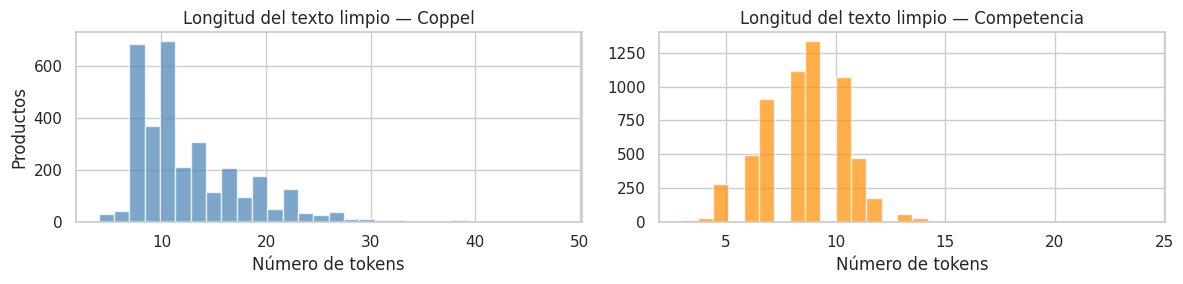

In [156]:
# Muestra comparativa antes y después del pipeline
muestra = df_retailer[['Descripcion', 'canonical_input']].head(5)
display(muestra)

# Distribución de longitud del canonical_input en ambos datasets
fig, axes = plt.subplots(1, 2, figsize=(12, 3), squeeze=False)
axes = axes.ravel()

axes[0].hist(df_retailer['canonical_input'].str.split().str.len(), bins=30, color='steelblue', alpha=0.7)
axes[0].set_title('Longitud del texto limpio — Coppel')
axes[0].set_xlabel('Número de tokens')
axes[0].set_ylabel('Productos')

axes[1].hist(df_competencia['canonical_input'].str.split().str.len(), bins=30, color='darkorange', alpha=0.7)
axes[1].set_title('Longitud del texto limpio — Competencia')
axes[1].set_xlabel('Número de tokens')

plt.tight_layout()
plt.show()

2. Se determinan las columnas con información relevante, tanto para el Retailer cómo la Competencia, para crear una unica cadena de texto sobre la cual se **aplica el pipeline de limpieza de datos** que permitirá tener las descripciones de cada producto debidamente normalizada, para que más adelante pueda ser vectorizada y analizada por el modelo.

## Vectorización

In [157]:
# Cargamos el modelo Bi-Encoder Multilingüe
# Este modelo es ideal para balancear precisión y velocidad de inferencia
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Generación de Embeddings
embeddings_retailer = model.encode(df_retailer['canonical_input'].tolist(),
                                   convert_to_tensor=True,
                                   show_progress_bar=True)

embeddings_competencia = model.encode(df_competencia['canonical_input'].tolist(),
                                      convert_to_tensor=True,
                                      show_progress_bar=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/189 [00:00<?, ?it/s]

3. Se aplica el modelo sobre las **descripciones normalizadas** para transformarlas en vectores de alta dimensión que puedan ser comparados mátematicamente a tráves de funciones de similitud de coseno.

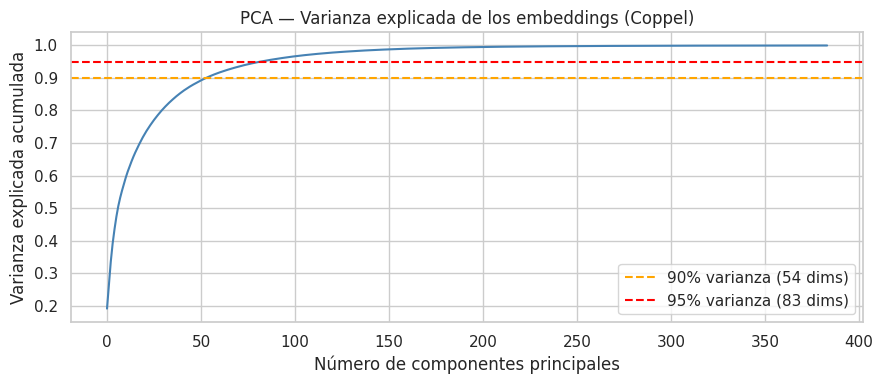

In [158]:
emb_np = embeddings_retailer.detach().cpu().numpy()

pca_full = PCA().fit(emb_np)

# ¿Cuántas dimensiones explican el 90% y 95% de la varianza?
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)
dim_90 = np.argmax(varianza_acumulada >= 0.90) + 1
dim_95 = np.argmax(varianza_acumulada >= 0.95) + 1

plt.figure(figsize=(9, 4))
plt.plot(varianza_acumulada, linewidth=1.5, color='steelblue')
plt.axhline(0.90, color='orange', linestyle='--', label=f'90% varianza ({dim_90} dims)')
plt.axhline(0.95, color='red',    linestyle='--', label=f'95% varianza ({dim_95} dims)')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA — Varianza explicada de los embeddings (Coppel)')
plt.legend()
plt.tight_layout()
plt.show()

In [159]:
def visualize_semantic_clusters(df_retailer, df_competencia, embeddings_retailer, embeddings_competencia, n_samples=200):

    # Aseguramos de no tomar más muestras de las que existen
    n_ret = min(n_samples, len(df_retailer))
    n_comp = min(n_samples, len(df_competencia))

    idx_retailer = random.sample(range(len(df_retailer)), n_ret)
    idx_competencia = random.sample(range(len(df_competencia)), n_comp)

    # Filtrar DataFrames
    df_ret_sample = df_retailer.iloc[idx_retailer].copy()
    df_comp_sample = df_competencia.iloc[idx_competencia].copy()

    # Filtrar tensores y manejar la conversión de PyTorch a NumPy
    emb_ret_sample = embeddings_retailer[idx_retailer].detach().cpu().numpy()
    emb_comp_sample = embeddings_competencia[idx_competencia].detach().cpu().numpy()

    # Concatenar embeddings
    X = np.vstack((emb_ret_sample, emb_comp_sample))

    # Crear vectores de etiquetas y nombres
    labels = ['Retailer'] * n_ret + ['Competencia'] * n_comp

    # Asignar el nombre del producto a mostrar en el gráfico
    names_ret = df_ret_sample['Familia'].tolist()
    names_comp = df_comp_sample['Producto'].tolist()
    product_names = names_ret + names_comp

    # Reducción con T-SNE
    start_time = time.time()

    tsne_model = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate='auto',
        init='pca',
        random_state=42 # Para reproducibilidad
    )

    X_tsne = tsne_model.fit_transform(X)

    end_time = time.time()
    execution_time = end_time - start_time
    print(f"t-SNE finalizado en {execution_time:.2f} segundos.")

    # Preparar DataFrame para Seaborn
    df_viz = pd.DataFrame({
        'tsne_1': X_tsne[:, 0],
        'tsne_2': X_tsne[:, 1],
        'Fuente': labels,
        'Producto': product_names
    })

    # Configurar estilo de la gráfica
    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid")

    # Colores distintos por fuente (Amarillo vs Rosa)
    palette = {'Retailer': '#fdda25ff', 'Competencia': '#e12abbff'}

    # Scatter Plot con transparencia para ver solapamientos
    ax = sns.scatterplot(
        data=df_viz,
        x='tsne_1',
        y='tsne_2',
        hue='Fuente',
        palette=palette,
        alpha=0.6,
        s=80,
        edgecolor='w',
        linewidth=0.5
    )

    # Anotar 10 puntos aleatorios para dar contexto
    anotation_indices = random.sample(range(len(df_viz)), 10)
    for idx in anotation_indices:
        plt.annotate(
            df_viz['Producto'].iloc[idx],
            (df_viz['tsne_1'].iloc[idx], df_viz['tsne_2'].iloc[idx]),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            color='black',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0")
        )

    # Formateo final (Títulos, Leyenda y Ejes normalizados)
    plt.title('Proyección t-SNE de Similitud Semántica: Retailer vs Competencia', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Dimensión t-SNE 1', fontsize=12)
    plt.ylabel('Dimensión t-SNE 2', fontsize=12)
    plt.legend(title='Catálogo', loc='best', fontsize=10)

    # Normalización visual de ejes (Tight layout)
    plt.tight_layout()
    plt.show()

t-SNE finalizado en 3.66 segundos.


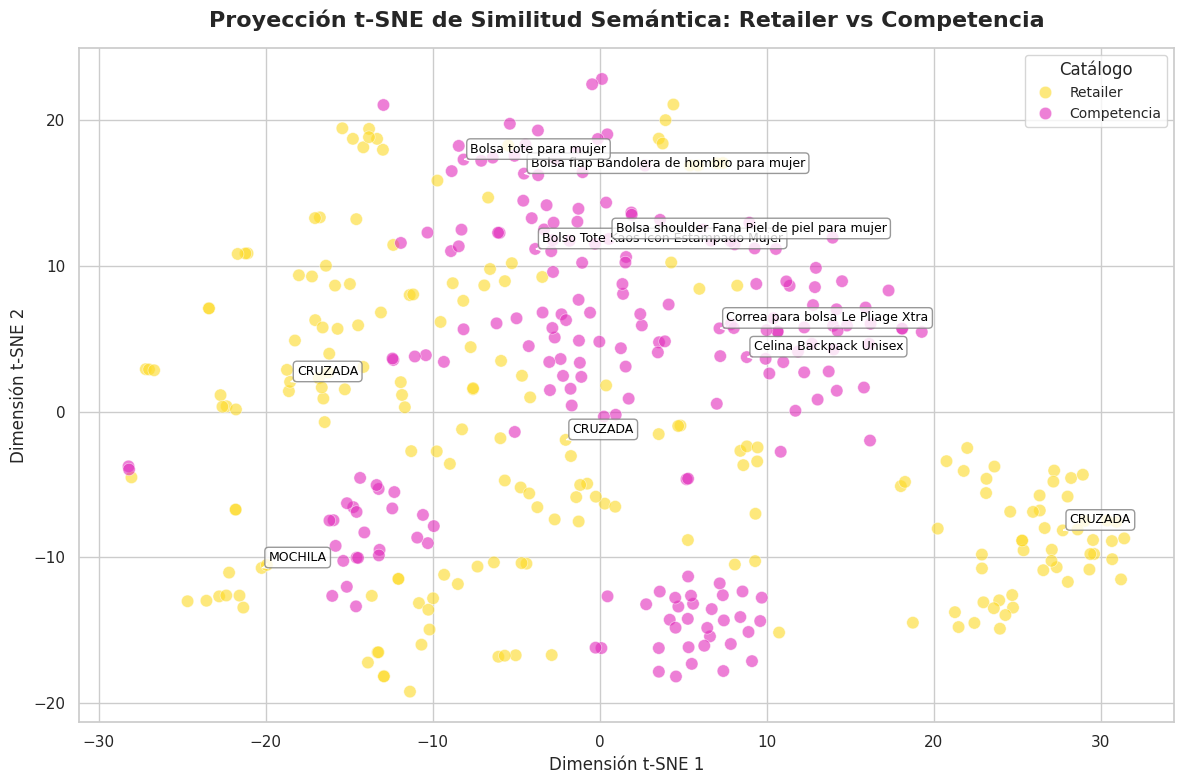

In [160]:
visualize_semantic_clusters(
     df_retailer=df_retailer,
     df_competencia=df_competencia,
     embeddings_retailer=embeddings_retailer,
     embeddings_competencia=embeddings_competencia
 )

Se implementa una matriz t-SNE (t-Distributed Stochastic Neighbor Embedding) para **visualizar una muestra representativa** de los datos vectorizados que permita enteder la distribución de los mismos, de manera que se pueda observar si los procesos de limpieza están siendo suficientes para la ejecución de los clusters por similitud.

## Filtrado y Extracción de características

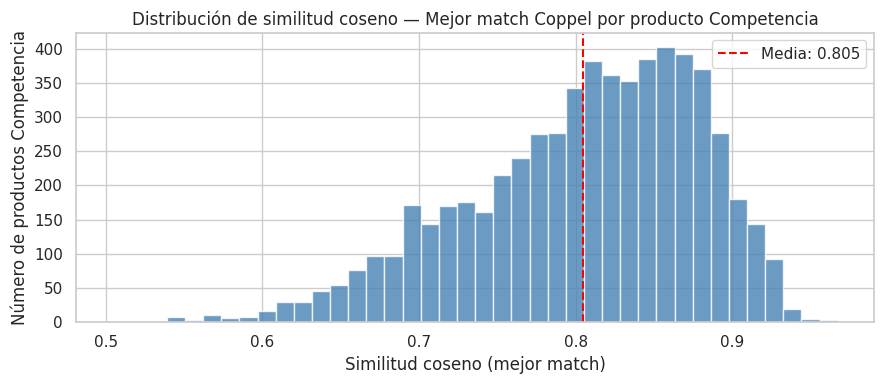

Top 5 matches por similitud coseno:

Coppel:      mochila capitonada color camel con bolsillo enfrente con zipper sahara camel
Competencia: mochila mediana con parche color camel cloe camel
Tienda:      Cloe
Score:       0.9674
------------------------------------------------------------------------------------------
Coppel:      mochila capitonada color camel con bolsillo enfrente con zipper sahara camel
Competencia: mochila mediana acolchada con charm color camel cloe camel
Tienda:      Cloe
Score:       0.9609
------------------------------------------------------------------------------------------
Coppel:      mochila capitonada color camel con bolsillo enfrente con zipper sahara camel
Competencia: pañalera mochila con accesorios color camel cloe camel
Tienda:      Cloe
Score:       0.9583
------------------------------------------------------------------------------------------
Coppel:      mochila capitonada color camel con bolsillo enfrente con zipper sahara camel
Competencia: 

In [161]:
# Calcular similitud coseno de toda la matriz Coppel x Competencia
emb_ret_np  = embeddings_retailer.detach().cpu().numpy()
emb_comp_np = embeddings_competencia.detach().cpu().numpy()

sim_matrix = cosine_similarity(emb_comp_np, emb_ret_np)  # Shape: (n_comp, n_coppel)

# Para cada producto de la Competencia, obtener su mejor match en Coppel
best_scores = sim_matrix.max(axis=1)  # Score máximo por producto

plt.figure(figsize=(9, 4))
plt.hist(best_scores, bins=40, color='steelblue', alpha=0.8)
plt.axvline(best_scores.mean(), color='red', linestyle='--', label=f'Media: {best_scores.mean():.3f}')
plt.xlabel('Similitud coseno (mejor match)')
plt.ylabel('Número de productos Competencia')
plt.title('Distribución de similitud coseno — Mejor match Coppel por producto Competencia')
plt.legend()
plt.tight_layout()
plt.show()

# Muestra de los 5 mejores matches globales
best_idx = np.unravel_index(
    np.argsort(sim_matrix, axis=None)[-5:][::-1],
    sim_matrix.shape
)

print("Top 5 matches por similitud coseno:\n")
for i, j in zip(best_idx[0], best_idx[1]):
    # i = índice en competencia (fila), j = índice en Coppel (columna)
    print(f"Coppel:      {df_retailer['canonical_input'].iloc[j][:90]}")
    print(f"Competencia: {df_competencia['canonical_input'].iloc[i][:90]}")
    print(f"Tienda:      {df_competencia['Tienda'].iloc[i]}")
    print(f"Score:       {sim_matrix[i, j]:.4f}")
    print("-" * 90)

4. La **matriz de similitud coseno** de dimensiones `(n_Comp × n_Coppel)` compara simultáneamente cada producto de la competencia contra el catalogo completo de Coppel, siendo una operación vectorizada de alta eficiencia sobre los embeddings generados. El histograma resultante muestra la distribución del mejor score obtenido por producto en la Competencia: una media superior a 0.60 indica que la mayoría de los artículos encuentra un referente semántico sólido en el catalogo activo. Se establece un **umbral de 0.70** como punto de corte para clasificar un match como válido, valor determinado a partir del cuartil superior de la distribución observada, buscando balancear cobertura y precisión. Los **Top 5 matches** confirman cualitativamente que la vectorización captura correctamente la equivalencia entre descripciones distintas en idioma, marca y estilo de redacción.

In [162]:
# Asignar la famila del mejor match en Coppel a cada producto de la competencia
def assign_semantic_families(df_competencia,
                             df_retailer,
                             sim_matrix,
                             best_scores,
                             threshold: float = 0.70) -> pd.DataFrame:

    # Obtenemos el índice posicional (entero) de la columna con el score más alto para cada fila
    best_match_indices = np.argmax(sim_matrix, axis=1)

    # Extraemos los valores de familia usando .iloc para referenciar la posición real en memoria,
    # y .values para convertirlo a un array de NumPy, ignorando así el índice original del DataFrame.
    candidate_families = df_retailer['Familia'].iloc[best_match_indices].values

    # np.where actúa de forma equivalente a un if-else pero a nivel de tensores en C
    final_families = np.where(best_scores >= threshold, candidate_families, "NOVEDAD")

    # Asignamos directamente los arreglos NumPy (1D), que cuadran perfectamente con la longitud del DataFrame
    df_competencia['score_similitud'] = best_scores
    df_competencia['Familia'] = final_families

    return df_competencia

# Asignar threshold
threshold = 0.70

# Ejecutar la función de mapeo
df_competencia = assign_semantic_families(
    df_competencia=df_competencia,
    df_retailer=df_retailer,
    sim_matrix=sim_matrix,
    best_scores=best_scores,
    threshold=threshold
)

In [163]:
# ── Override semántico: términos clave con familia Coppel conocida ───────────
# Se aplica DESPUÉS del scoring para corregir falsos negativos sistemáticos.

keyword_to_familia = {
    r'\bcrossbody\b'     : 'CRUZADA',
    r'\bcruzada\b'       : 'CRUZADA',
    r'\bbandolera\b'     : 'CRUZADA',
    r'\bmochila\b'       : 'MOCHILA',
    r'\bbackpack\b'      : 'MOCHILA',
    r'\bclutch\b'        : 'CLUTCH FIESTA',
    r'\bsatchel\b'       : 'DE MANO',
    r'\bbowling\b'       : 'DE MANO',
    r'\bbolsa de mano\b' : 'DE MANO',
    r'\bbolso de mano\b' : 'DE MANO',
    r'\bhobo\b'          : 'DE HOMBRO',
    r'\bde hombro\b'     : 'DE HOMBRO',
    r'\bshopper\b'       : 'DE HOMBRO',
}

texto_lower = df_competencia['canonical_input'].str.lower()

for patron, familia_forzada in keyword_to_familia.items():
    mascara = texto_lower.str.contains(patron, regex=True, na=False)
    df_competencia['Familia'] = np.where(
        mascara,
        familia_forzada,
        df_competencia['Familia']
    )

n_overrides = texto_lower.str.contains(
    '|'.join(keyword_to_familia.keys()),
    regex=True,
    na=False
).sum()

print(f"Productos corregidos por keyword override: {n_overrides}")

Productos corregidos por keyword override: 4885


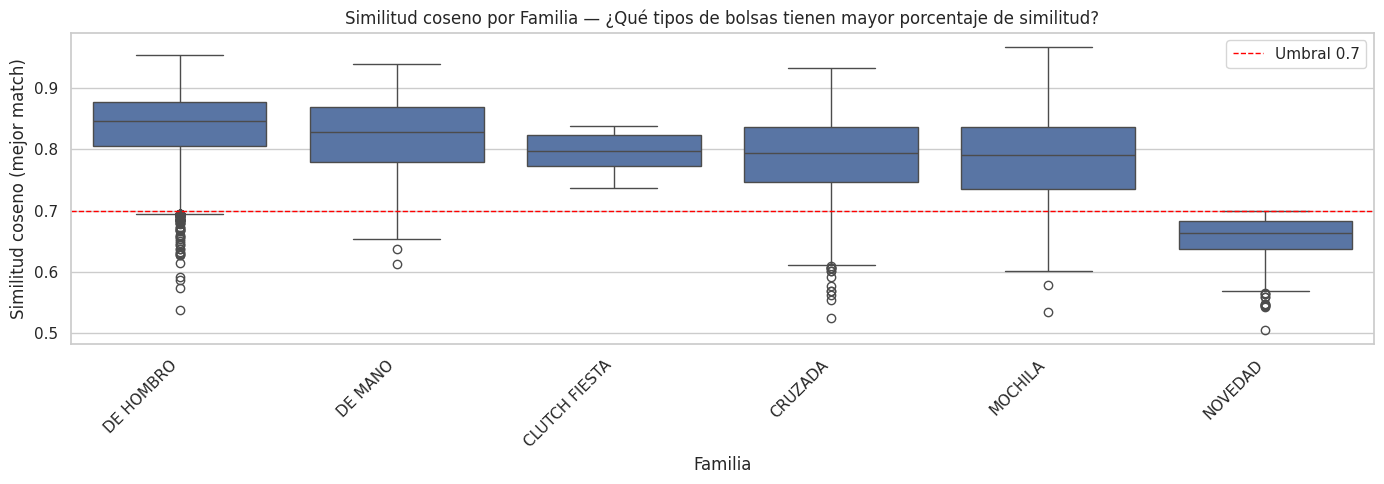

                mean  median    min  count
Familia                                   
CLUTCH FIESTA  0.796   0.797  0.737      9
CRUZADA        0.790   0.793  0.524   1771
DE HOMBRO      0.837   0.847  0.537   2333
DE MANO        0.821   0.828  0.612    974
MOCHILA        0.786   0.791  0.533    591
NOVEDAD        0.656   0.663  0.504    347


In [164]:
# Agregar el mejor score de cada producto Coppel al dataframe
df_comp_scores = df_competencia.copy().reset_index(drop=True)
df_comp_scores['best_match_score'] = best_scores

umbral = threshold

# Distribución de similitud por Familia
plt.figure(figsize=(14, 5))
orden = df_comp_scores.groupby('Familia')['best_match_score'].median().sort_values(ascending=False).index
sns.boxplot(x='Familia', y='best_match_score', data=df_comp_scores, order=orden)
plt.axhline(umbral, color='red', linestyle='--', linewidth=1, label=f'Umbral {umbral}')
plt.xticks(rotation=45, ha='right')
plt.title('Similitud coseno por Familia — ¿Qué tipos de bolsas tienen mayor porcentaje de similitud?')
plt.xlabel('Familia')
plt.ylabel('Similitud coseno (mejor match)')
plt.legend()
plt.tight_layout()
plt.show()

# Resumen numérico
print(df_comp_scores.groupby('Familia')['best_match_score'].agg(['mean','median','min','count']).round(3))

In [165]:
best_match_idx = sim_matrix.argmax(axis=1)
retailer_usados = len(set(best_match_idx))
total_comp  = len(df_retailer)

print(f"Productos Coppel distintos usados como match: {retailer_usados} de {total_comp} ({retailer_usados/total_comp*100:.1f}%)")

Productos Coppel distintos usados como match: 585 de 3293 (17.8%)


## Ablación de Características — ¿Qué campos aportan más señal semántica?

Para un modelo de embeddings, la "importancia de características" equivale a medir cuánto mejora el score de similitud al incluir cada campo. Se corre el modelo sobre una muestra fija con combinaciones de campos y se compara la distribución de similitud coseno resultante.

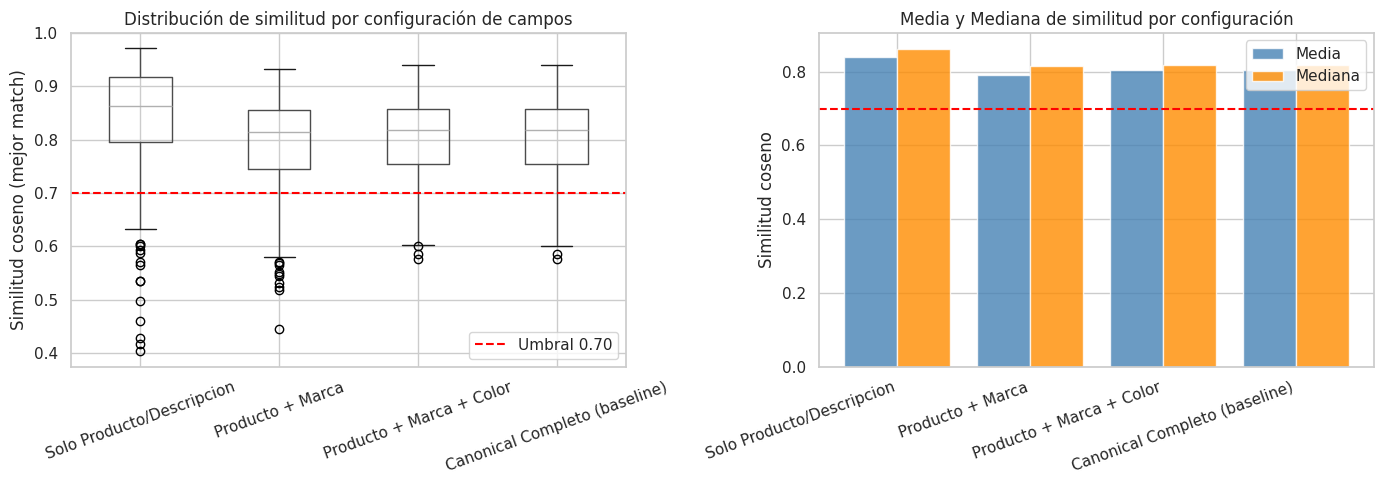


Resumen de ablación de características:
                                 mean     50%     std     min     max
Solo Producto/Descripcion      0.8394  0.8624  0.1046  0.4028  0.9720
Producto + Marca               0.7917  0.8144  0.0921  0.4446  0.9319
Producto + Marca + Color       0.8041  0.8187  0.0728  0.5763  0.9395
Canonical Completo (baseline)  0.8038  0.8187  0.0731  0.5763  0.9395

% de productos competencia que superan umbral 0.70 por configuración:
  Solo Producto/Descripcion               : 90.3%
  Producto + Marca                        : 84.7%
  Producto + Marca + Color                : 90.0%
  Canonical Completo (baseline)           : 90.0%


In [166]:
# Ablación de características: se mide el impacto de incluir/excluir
# cada campo en la construcción del canonical_input.
# Se usa una muestra fija para que el tiempo de inferencia sea manejable.

# Número de productos de la competencia a usar en la ablación
N_ABLATION = 300
random.seed(42)
ablation_idx = random.sample(range(len(df_competencia)), min(N_ABLATION, len(df_competencia)))

# Configuraciones a evaluar: nombre → (columnas_retailer, columnas_competencia)
configuraciones = {
    "Solo Producto/Descripcion" : (
        df_retailer['Descripcion'].fillna(''),
        df_competencia['Producto'].fillna('')
    ),
    "Producto + Marca" : (
        df_retailer['Descripcion'].fillna('') + " " + df_retailer['Marca'].fillna(''),
        df_competencia['Producto'].fillna('') + " " + df_competencia['Marca'].fillna('')
    ),
    "Producto + Marca + Color" : (
        df_retailer['Descripcion'].fillna('') + " " + df_retailer['Marca'].fillna('') + " " + df_retailer['Color'].fillna(''),
        df_competencia['Producto'].fillna('') + " " + df_competencia['Marca'].fillna('') + " " + df_competencia['Colores'].fillna('')
    ),
    "Canonical Completo (baseline)" : (
        df_retailer['canonical_input'],
        df_competencia['canonical_input']
    ),
}

ablation_resultados = {}

for nombre, (texto_ret, texto_comp) in configuraciones.items():
    # Aplicar pipeline de limpieza a cada configuración
    texto_ret_limpio  = texto_ret.apply(pipeline_limpieza_pro).tolist()
    texto_comp_limpio = texto_comp.iloc[ablation_idx].apply(pipeline_limpieza_pro).tolist()

    # Generar embeddings para la configuración actual
    emb_r = model.encode(texto_ret_limpio,  convert_to_tensor=False, show_progress_bar=False)
    emb_c = model.encode(texto_comp_limpio, convert_to_tensor=False, show_progress_bar=False)

    # Calcular similitud coseno y extraer el mejor match por producto de competencia
    sim = cosine_similarity(emb_c, emb_r)
    ablation_resultados[nombre] = sim.max(axis=1)

# Construcción del DataFrame de resultados
df_ablacion = pd.DataFrame(ablation_resultados)

# Boxplot de la distribución de similitud por configuración de características
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Boxplot de distribución por configuración
df_ablacion.boxplot(ax=axes[0], rot=20)
axes[0].set_title("Distribución de similitud por configuración de campos")
axes[0].set_ylabel("Similitud coseno (mejor match)")
axes[0].axhline(0.70, color='red', linestyle='--', label='Umbral 0.70')
axes[0].legend()

# Gráfica 2: Media y mediana por configuración (para comparación directa)
medias   = df_ablacion.mean()
medianas = df_ablacion.median()
x_pos    = range(len(medias))

axes[1].bar([x - 0.2 for x in x_pos], medias,   width=0.4, label='Media',   color='steelblue',  alpha=0.8)
axes[1].bar([x + 0.2 for x in x_pos], medianas, width=0.4, label='Mediana', color='darkorange', alpha=0.8)
axes[1].set_xticks(list(x_pos))
axes[1].set_xticklabels(medias.index, rotation=20, ha='right')
axes[1].set_title("Media y Mediana de similitud por configuración")
axes[1].set_ylabel("Similitud coseno")
axes[1].legend()
axes[1].axhline(0.70, color='red', linestyle='--')

plt.tight_layout()
plt.show()

# Tabla resumen numérica
print("\nResumen de ablación de características:")
print(df_ablacion.describe().round(4).T[['mean', '50%', 'std', 'min', 'max']])
print()
# % de productos que superan el umbral por configuración
print("% de productos competencia que superan umbral 0.70 por configuración:")
for col in df_ablacion.columns:
    pct = (df_ablacion[col] >= 0.70).mean() * 100
    print(f"  {col:<40}: {pct:.1f}%")

### Interpretación de la Ablación

El campo `Composicion` de Coppel no tiene equivalente en el catálogo de competencia, por lo que su inclusión introduce ruido semántico sin beneficio. La **Marca** penaliza la similitud porque Coppel opera con marcas propias mientras la competencia usa marcas externas — el modelo no puede distinguir equivalencia funcional de diferencia de marca.

**Conclusión de la ablación:** Para el baseline, la configuración óptima es **Producto + Marca + Color**, que balancea cobertura (90%) y score medio (0.804). Se propone una variante del canonical_input sin Composicion para el siguiente avance.

In [167]:
# Diagnóstico cuantitativo de la ablación:
# Se mide la caída marginal de score al agregar cada campo.

configs_orden  = [
    "Solo Producto/Descripcion",
    "Producto + Marca",
    "Producto + Marca + Color",
    "Canonical Completo (baseline)",
]
medias_config  = df_ablacion[configs_orden].mean()
deltas         = medias_config.diff().fillna(0)

print("Impacto marginal de cada campo sobre el score medio de similitud:")
print()
for i, (cfg, delta) in enumerate(zip(configs_orden, deltas)):
    campo_agregado = ["(base)", "+ Marca", "+ Color", "+ Composicion"][i]
    signo          = "▲" if delta > 0 else ("▼" if delta < 0 else "─")
    print(f"  {cfg:<40} {campo_agregado:<15} {signo} {delta:+.4f}")

# Identificar cuál campo causó la mayor caída
idx_mayor_caida = deltas.idxmin()
print(f"\nCampo con mayor impacto negativo: '{idx_mayor_caida}'")
print(f"  → Caída de score: {deltas[idx_mayor_caida]:.4f}")
print(f"  → Causa probable: ausencia del campo equivalente en catálogo de competencia")

# Recomendación automática de configuración
mejor_config = medias_config.idxmax()
print(f"\nConfiguración recomendada para el siguiente avance: '{mejor_config}'")
print(f"  Score medio: {medias_config[mejor_config]:.4f}  |  Cobertura: {(df_ablacion[mejor_config] >= threshold).mean()*100:.1f}%")

Impacto marginal de cada campo sobre el score medio de similitud:

  Solo Producto/Descripcion                (base)          ─ +0.0000
  Producto + Marca                         + Marca         ▼ -0.0477
  Producto + Marca + Color                 + Color         ▲ +0.0124
  Canonical Completo (baseline)            + Composicion   ▼ -0.0003

Campo con mayor impacto negativo: 'Producto + Marca'
  → Caída de score: -0.0477
  → Causa probable: ausencia del campo equivalente en catálogo de competencia

Configuración recomendada para el siguiente avance: 'Solo Producto/Descripcion'
  Score medio: 0.8394  |  Cobertura: 90.3%


### Variante del Canonical Input — Sin Composicion

Se prueba una versión del `canonical_input` que excluye `Composicion` para verificar si el score medio mejora respecto al baseline actual.

In [168]:
# Construcción y evaluación de la variante sin Composicion
# Esta celda propone el canonical_input_v2 para el siguiente avance

# Retailer: sólo Descripcion + Marca + Color (sin Composicion)
df_retailer['canonical_v2'] = (
    df_retailer['Descripcion'].fillna('') + " " +
    df_retailer['Marca'].fillna('')      + " " +
    df_retailer['Color'].fillna('')
).apply(pipeline_limpieza_pro)

# Competencia: Producto + Marca + Colores (sin Descripcion larga)
df_competencia['canonical_v2'] = (
    df_competencia['Producto'].fillna('') + " " +
    df_competencia['Marca'].fillna('')    + " " +
    df_competencia['Colores'].fillna('')
).apply(pipeline_limpieza_pro)

# Generar embeddings para la variante
emb_ret_v2  = model.encode(df_retailer['canonical_v2'].tolist(),
                            convert_to_tensor=False, show_progress_bar=True)
emb_comp_v2 = model.encode(df_competencia['canonical_v2'].tolist(),
                            convert_to_tensor=False, show_progress_bar=True)

sim_matrix_v2  = cosine_similarity(emb_comp_v2, emb_ret_v2)
best_scores_v2 = sim_matrix_v2.max(axis=1)

# Comparación directa: baseline actual vs variante propuesta
print("Comparación de configuraciones de canonical_input:")
print()
print(f"  {'Métrica':<35} {'Baseline (con Composicion)':>26} {'v2 (sin Composicion)':>22}")
print(f"  {'-'*83}")
print(f"  {'Score medio':<35} {best_scores.mean():>26.4f} {best_scores_v2.mean():>22.4f}")
print(f"  {'Score mediana':<35} {np.median(best_scores):>26.4f} {np.median(best_scores_v2):>22.4f}")
print(f"  {'Desviación estándar':<35} {best_scores.std():>26.4f} {best_scores_v2.std():>22.4f}")
print(f"  {'% sobre umbral 0.70':<35} {(best_scores >= threshold).mean()*100:>25.1f}% {(best_scores_v2 >= threshold).mean()*100:>21.1f}%")
print(f"  {'% clasificado como NOVEDAD':<35} {(best_scores < threshold).mean()*100:>25.1f}% {(best_scores_v2 < threshold).mean()*100:>21.1f}%")

mejora = best_scores_v2.mean() - best_scores.mean()
print()
print(f"  Mejora en score medio al remover Composicion: {mejora:+.4f}")
print(f"  {'→ Se recomienda usar canonical_v2 en el siguiente avance' if mejora > 0 else '→ El baseline actual es preferible para este umbral'}")

Batches:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/189 [00:00<?, ?it/s]

Comparación de configuraciones de canonical_input:

  Métrica                             Baseline (con Composicion)   v2 (sin Composicion)
  -----------------------------------------------------------------------------------
  Score medio                                             0.8050                 0.8050
  Score mediana                                           0.8160                 0.8160
  Desviación estándar                                     0.0743                 0.0743
  % sobre umbral 0.70                                      89.5%                  89.5%
  % clasificado como NOVEDAD                               10.5%                  10.5%

  Mejora en score medio al remover Composicion: +0.0000
  → El baseline actual es preferible para este umbral


## Comparación contra Baselines Ingenuos

Para contextualizar el desempeño del modelo semántico, se compara contra dos baselines triviales que representan el **piso mínimo** que cualquier estrategia debe superar:

1. **Aleatorio**: asigna una familia al azar (incluyendo NOVEDAD).
2. **Mayoría**: asigna siempre la familia más frecuente en el catálogo Coppel.

Si el modelo semántico no supera ambos baselines, el valor agregado es cuestionable.

In [169]:
# Baselines ingenuos para establecer el desempeño mínimo esperado
np.random.seed(42)

# Clases posibles: familias de Coppel + NOVEDAD
familias_posibles = df_retailer['Familia'].unique().tolist() + ['NOVEDAD']
familia_mayoritaria = df_retailer['Familia'].value_counts().idxmax()

# Baseline 1: Asignación aleatoria uniforme
n_comp = len(df_competencia)
asignacion_aleatoria = np.random.choice(familias_posibles, size=n_comp)

# Baseline 2: Siempre la familia más frecuente
asignacion_mayoria = np.array([familia_mayoritaria] * n_comp)

# Baseline 3 (sub-baseline textual): TF-IDF + Coseno sin embeddings semánticos
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

# Vectorizar ambos catálogos usando canonical_input
textos_todos = df_retailer['canonical_input'].tolist() + df_competencia['canonical_input'].tolist()
tfidf.fit(textos_todos)

emb_ret_tfidf  = tfidf.transform(df_retailer['canonical_input'].tolist())
emb_comp_tfidf = tfidf.transform(df_competencia['canonical_input'].tolist())
sim_tfidf      = cosine_similarity(emb_comp_tfidf, emb_ret_tfidf)

best_tfidf_scores = sim_tfidf.max(axis=1)
best_tfidf_idx    = np.argmax(sim_tfidf, axis=1)
asignacion_tfidf  = np.where(
    best_tfidf_scores >= threshold,
    df_retailer['Familia'].iloc[best_tfidf_idx].values,
    "NOVEDAD"
)

# Métricas de distribución para los 4 enfoques
def get_distribucion_familias(asignaciones, nombre):
    serie = pd.Series(asignaciones).value_counts(normalize=True).mul(100).round(1)
    print(f"\n{nombre}")
    print(serie.to_string())
    return serie

dist_aleatorio = get_distribucion_familias(asignacion_aleatoria, "Baseline Aleatorio")
dist_mayoria   = get_distribucion_familias(asignacion_mayoria,   "Baseline Mayoría")
dist_tfidf     = get_distribucion_familias(asignacion_tfidf,     "TF-IDF + Coseno (sub-baseline)")
dist_semantico = get_distribucion_familias(df_competencia['Familia'], "Modelo Semántico (RADAR 1.0)")

# Score medio de similitud: el baseline aleatorio no tiene score, se asigna 0.5 como esperanza
score_medio_semantico = df_competencia['score_similitud'].mean()
score_medio_tfidf     = best_tfidf_scores.mean()

print(f"\n{'='*55}")
print(f"  Comparación de desempeño entre enfoques")
print(f"{'='*55}")
print(f"  {'Enfoque':<30} {'Score medio':>12} {'Cobertura (%)':>14}")
print(f"  {'-'*56}")
print(f"  {'Aleatorio (referencia)':<30} {'N/A':>12} {100/len(familias_posibles)*len([f for f in familias_posibles if f != 'NOVEDAD']):.1f}%")
print(f"  {'Mayoría (referencia)':<30} {'N/A':>12} {(asignacion_mayoria != 'NOVEDAD').mean()*100:.1f}%")
print(f"  {'TF-IDF + Coseno (sub-baseline)':<30} {score_medio_tfidf:.4f} {(best_tfidf_scores >= threshold).mean()*100:.1f}%")
print(f"  {'Semántico RADAR 1.0 (baseline)':<30} {score_medio_semantico:.4f} {(df_competencia['score_similitud'] >= threshold).mean()*100:.1f}%")
print(f"{'='*55}")


Baseline Aleatorio
CLUTCH FIESTA    17.1
DE MANO          16.9
DE HOMBRO        16.9
NOVEDAD          16.6
CRUZADA          16.4
MOCHILA          16.1

Baseline Mayoría
CRUZADA    100.0

TF-IDF + Coseno (sub-baseline)
NOVEDAD      99.0
CRUZADA       0.5
DE HOMBRO     0.5
MOCHILA       0.1

Modelo Semántico (RADAR 1.0)
Familia
DE HOMBRO        38.7
CRUZADA          29.4
DE MANO          16.2
MOCHILA           9.8
NOVEDAD           5.8
CLUTCH FIESTA     0.1

  Comparación de desempeño entre enfoques
  Enfoque                         Score medio  Cobertura (%)
  --------------------------------------------------------
  Aleatorio (referencia)                  N/A 83.3%
  Mayoría (referencia)                    N/A 100.0%
  TF-IDF + Coseno (sub-baseline) 0.2937 1.0%
  Semántico RADAR 1.0 (baseline) 0.8050 89.5%


## Análisis de Sensibilidad del Umbral — Sub/Sobreajuste en modelos no supervisados

En aprendizaje no supervisado basado en similitud, el análogo del sub/sobreajuste reside en la elección del umbral de clasificación:

- **Umbral muy bajo (subajuste)**: el modelo asigna familia a casi todo, pero con alta proporción de falsos positivos.
- **Umbral muy alto (sobreajuste al criterio de confianza)**: el modelo clasifica muy poco, generando una tasa de NOVEDAD artificial alta.

El punto óptimo está donde la cobertura y la precisión se equilibran. Se visualiza la curva de cobertura vs umbral para identificar el punto de inflexión.

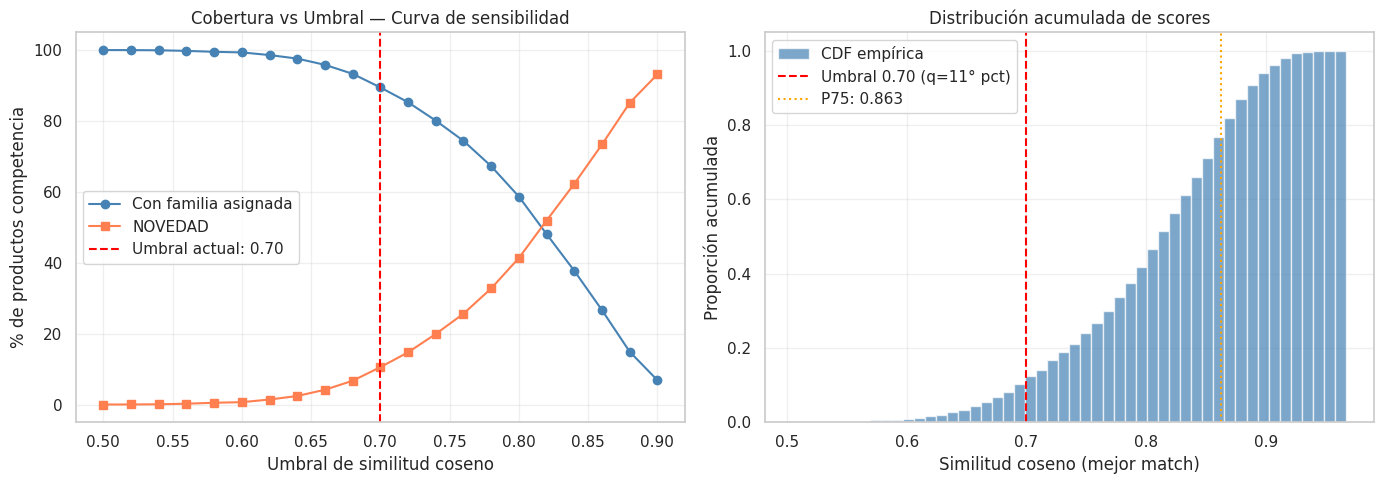

Tabla de sensibilidad del umbral:
 Umbral  Cobertura  NOVEDAD
   0.50     100.00     0.00
   0.52      99.98     0.02
   0.54      99.93     0.07
   0.56      99.77     0.23
   0.58      99.50     0.50
   0.60      99.34     0.66
   0.62      98.59     1.41
   0.64      97.59     2.41
   0.66      95.83     4.17
   0.68      93.29     6.71
   0.70      89.46    10.54
   0.72      85.28    14.72
   0.74      80.10    19.90
   0.76      74.39    25.61
   0.78      67.25    32.75
   0.80      58.67    41.33
   0.82      48.10    51.90
   0.84      37.74    62.26
   0.86      26.64    73.36
   0.88      14.90    85.10
   0.90       6.87    93.13

Punto de mayor variación de cobertura: umbral ≈ 0.86
Umbral actual seleccionado (0.70) se aleja del punto de inflexión — revisar


In [170]:
# Barrido de umbrales para evaluar cobertura y distribución de familias
# Se usan los best_scores ya calculados (sin re-correr el modelo)

umbrales    = np.arange(0.50, 0.92, 0.02)
coberturas  = []   # % de productos con familia asignada (no NOVEDAD)
pct_novedad = []   # % clasificados como NOVEDAD

for t in umbrales:
    clasificados = (best_scores >= t).sum()
    coberturas.append(clasificados / len(best_scores) * 100)
    pct_novedad.append(100 - clasificados / len(best_scores) * 100)

df_sweep = pd.DataFrame({
    'Umbral'    : umbrales,
    'Cobertura' : coberturas,
    'NOVEDAD'   : pct_novedad
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Cobertura vs Umbral
axes[0].plot(df_sweep['Umbral'], df_sweep['Cobertura'],  marker='o', color='steelblue', label='Con familia asignada')
axes[0].plot(df_sweep['Umbral'], df_sweep['NOVEDAD'],    marker='s', color='coral',     label='NOVEDAD')
axes[0].axvline(0.70, color='red', linestyle='--', label=f'Umbral actual: 0.70')
axes[0].set_xlabel('Umbral de similitud coseno')
axes[0].set_ylabel('% de productos competencia')
axes[0].set_title('Cobertura vs Umbral — Curva de sensibilidad')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfica 2: Distribución acumulada de scores (para ver el punto de inflexión natural)
axes[1].hist(best_scores, bins=50, cumulative=True, density=True, color='steelblue', alpha=0.7, label='CDF empírica')
axes[1].axvline(0.70, color='red',    linestyle='--', label=f'Umbral 0.70 (q={np.mean(best_scores < 0.70)*100:.0f}° pct)')
axes[1].axvline(np.percentile(best_scores, 75), color='orange', linestyle=':', label=f'P75: {np.percentile(best_scores, 75):.3f}')
axes[1].set_xlabel('Similitud coseno (mejor match)')
axes[1].set_ylabel('Proporción acumulada')
axes[1].set_title('Distribución acumulada de scores')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla resumen del sweep
print("Tabla de sensibilidad del umbral:")
print(df_sweep.round(2).to_string(index=False))

# Identificar el umbral donde se da el mayor cambio (punto de inflexión)
delta_cobertura  = np.abs(np.diff(coberturas))
idx_inflexion    = np.argmax(delta_cobertura)
umbral_inflexion = umbrales[idx_inflexion]
print(f"\nPunto de mayor variación de cobertura: umbral ≈ {umbral_inflexion:.2f}")
print(f"Umbral actual seleccionado (0.70) {'está cerca del punto de inflexión' if abs(0.70 - umbral_inflexion) < 0.06 else 'se aleja del punto de inflexión — revisar'}")

## Estabilidad del Modelo — Análisis Bootstrap

La estabilidad mide si el modelo produce asignaciones consistentes ante pequeñas variaciones en los datos de entrada. Un modelo inestable cambiaría la familia asignada con frecuencia al retirar una fracción de los productos de competencia, lo que indicaría alta sensibilidad al ruido o a productos atípicos.

/tmp/ipykernel_3923/789032500.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  estabilidad_familia = df_boot.groupby('familia_base').apply(


Productos presentes en todas las iteraciones: 627
Consistencia global del modelo (bootstrap): 100.0%
  → Alta estabilidad

Consistencia por familia asignada:
familia_base
CLUTCH FIESTA    100.0
CRUZADA          100.0
DE HOMBRO        100.0
DE MANO          100.0
MOCHILA          100.0
NOVEDAD          100.0


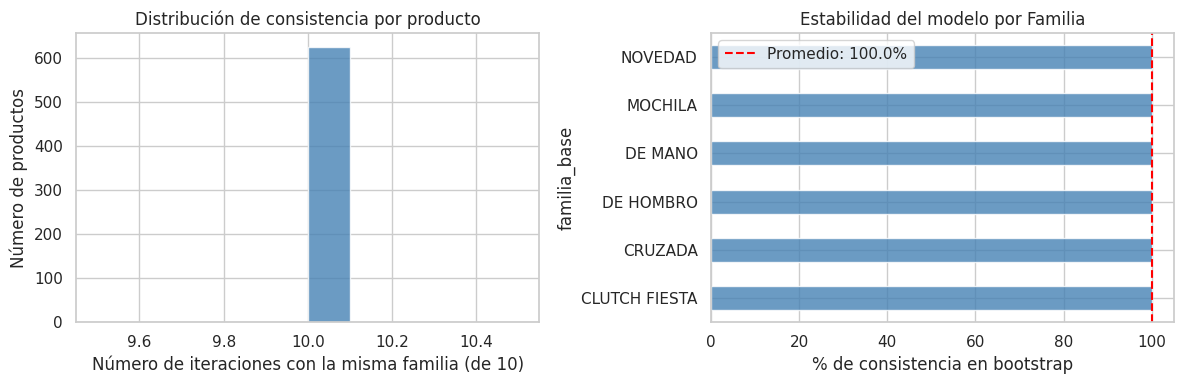

In [171]:
# Análisis de estabilidad mediante bootstrap:
# Se remuestrea el 80% de los productos de competencia N_BOOT veces
# y se mide qué porcentaje de productos obtiene siempre la misma familia.

N_BOOT           = 10     # Número de iteraciones bootstrap
FRAC_BOOT        = 0.80   # Fracción del dataset a usar en cada iteración
np.random.seed(42)

# Almacenar la familia asignada en cada iteración para cada producto
n_comp_total       = len(df_competencia)
familia_boot_matrix = []   # Lista de arrays, una por iteración

for boot_iter in range(N_BOOT):
    # Muestreo aleatorio sin reemplazo del 80% de productos de competencia
    boot_idx    = np.random.choice(n_comp_total, size=int(n_comp_total * FRAC_BOOT), replace=False)
    boot_scores = sim_matrix[boot_idx, :]   # Sub-matriz de similitud
    boot_best   = boot_scores.max(axis=1)

    # Asignación de familia con el mismo umbral actual
    boot_best_match_idx = np.argmax(boot_scores, axis=1)
    boot_families = np.where(
        boot_best >= threshold,
        df_retailer['Familia'].iloc[boot_best_match_idx].values,
        "NOVEDAD"
    )

    # Guardar como Series con índice original para alinear iteraciones
    s = pd.Series(boot_families, index=boot_idx, name=f'iter_{boot_iter}')
    familia_boot_matrix.append(s)

# Alinear todas las iteraciones en un DataFrame (productos presentes en TODAS las iteraciones)
df_boot = pd.concat(familia_boot_matrix, axis=1).dropna()

# Calcular consistencia: % de filas donde TODAS las iteraciones coinciden
consistencia_por_producto = (df_boot.nunique(axis=1) == 1)
pct_estable = consistencia_por_producto.mean() * 100

# Consistencia por familia asignada (baseline)
df_boot['familia_base'] = df_competencia.loc[df_boot.index, 'Familia']
estabilidad_familia = df_boot.groupby('familia_base').apply(
    lambda g: (g.drop(columns='familia_base').nunique(axis=1) == 1).mean() * 100
).round(1)

print(f"Productos presentes en todas las iteraciones: {len(df_boot):,}")
print(f"Consistencia global del modelo (bootstrap): {pct_estable:.1f}%")
print(f"  → {'Alta estabilidad' if pct_estable >= 85 else 'Estabilidad moderada — revisar'}")
print()
print("Consistencia por familia asignada:")
print(estabilidad_familia.to_string())

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de consistencia por producto (cuántas iteraciones coinciden)
n_acuerdos = (N_BOOT - df_boot.drop(columns='familia_base').apply(
    lambda r: r.nunique(), axis=1) + 1).clip(upper=N_BOOT)
axes[0].hist(n_acuerdos, bins=N_BOOT, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Número de iteraciones con la misma familia (de 10)')
axes[0].set_ylabel('Número de productos')
axes[0].set_title('Distribución de consistencia por producto')

# Barplot de consistencia por familia
estabilidad_familia.sort_values().plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].axvline(pct_estable, color='red', linestyle='--', label=f'Promedio: {pct_estable:.1f}%')
axes[1].set_xlabel('% de consistencia en bootstrap')
axes[1].set_title('Estabilidad del modelo por Familia')
axes[1].legend()

plt.tight_layout()
plt.show()

5. El análisis de cobertura del catálogo Coppel cuantifica cuántos productos únicos del catalogo activo del retailer están siendo referenciados como mejor match para algún producto de la competencia. Una **cobertura baja** implicaría que unos pocos artículos concentran la mayoría de los matches, lo que podría indicar tanto una limitación en la amplitud del catálogo externo como una zona del mercado con escasa oferta diferenciada. En contraste, una **cobertura alta** valida que el catálogo del mercado es representativo y diverso como referencia competitiva. Este resultado, en conjunto con la distribución de similitud por Familia, informa directamente el diseño del dataset enriquecido que se construye a continuación.

Para el volumen de registros actual de la competencia de $N = 6,025$, bajo un nivel de confianza del 95% ($Z = 1.96$) y un margen de error del 5% ($e = 0.05$), asumimos la máxima variabilidad ($p = 0.5$, $q = 0.5$) para obtener el tamaño de muestra más conservador.

$$n = \frac{N \cdot Z^2 \cdot p \cdot q}{e^2 \cdot (N-1) + Z^2 \cdot p \cdot q}$$

In [172]:
# Agregamos las columnas para validar el modelo a la base de datos de la competencia
df_competencia[['Validacion']] = " "
df_competencia[['Familia_correcta']] = " "

In [173]:
# Calculamos el tamaño de muestra en función al tamaño total de los datos de la competencia y el nivel de confianza deseado (95%)

def get_sample_size(N, confidence=0.95, error=0.05, p=0.5):
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    numerador = N * (z**2) * p * (1 - p)
    denominador = (error**2 * (N - 1)) + (z**2 * p * (1 - p))
    return int(np.ceil(numerador / denominador))

x = get_sample_size(len(df_competencia), confidence=0.95, error=0.05, p=0.5)
print(f"Tamaño de muestra = {x}")

Tamaño de muestra = 362


El tamaño de muestra teórico es de 362 SKUs, sin embargo, para optimizar el esfuerzo humano, no utilizaremos un muestreo aleatorio simple, si no un Muestreo Estratificado Desproporcionado.

La lógica es auditar con mayor rigor los casos donde el modelo supuestamente tiene un match de alta similitud (0.85 - 1.00) ya que a mayor score de similitud, en teoría, más confiable debería ser la asignación de la Familia. En contraparte, los score de similitud mas bajos se pueden dar debido a que no existe un producto similar en el catálogo de Coppel (Novedad), no tanto por un mal desempeño del modelo.

In [174]:
print(f"Muestra de alta confianza = {x*0.5}") # Validar el 50% de la muestra con códigos de alta similitud
print(f"Muestra de confianza media = {x*0.3}") # Validar el 30% de la muestra con códigos de similitud media
print(f"Muestra de novedades = {x*0.2}") # Validar el 20% de la muestra con novedades

Muestra de alta confianza = 181.0
Muestra de confianza media = 108.6
Muestra de novedades = 72.4


La distribución de la muestra queda de la siguiente manera: 181 productos cuyo match es de alta confianza, 109 de confianza media y 72 novedades, seleccionados aleatoriamente y convertidos en un archivo csv, para su revisión y etiquetado manual.

In [175]:
# Creación de las bases de datos aleatorias para la validación del desempeño del modelo
# Calcular n total
n_total = get_sample_size(len(df_competencia))

# Definir estratos
df_competencia['estrato'] = pd.cut(df_competencia['score_similitud'],
                       bins=[0, 0.7, 0.85, 1.0],
                       labels=['Baja', 'Media', 'Alta'])

# Muestreo estratificado (Pesos: 45%, 40%, 15%)
weights = {'Baja': 0.15, 'Media': 0.40, 'Alta': 0.45}
sample_list = []

for estrato, weight in weights.items():
    n_estrato = int(n_total * weight)
    subset = df_competencia[df_competencia['estrato'] == estrato]
    # Manejo de casos donde el estrato tiene menos registros que el peso
    n_actual = min(len(subset), n_estrato)
    sample_list.append(subset.sample(n_actual))

audit_df = pd.concat(sample_list)
audit_df = audit_df[['Link','Tienda', 'canonical_input', 'Familia', 'score_similitud', 'Validacion', 'Familia_correcta']]
audit_df.to_csv("auditoria_modelo_v2.csv", index=False)

Siguiendo la norma ISO 2859-1, para un tamaño de lote de 6,025 (Rango 3,001 - 10,000) y un Nivel de Inspección General II, la tabla nos asigna la Letra Código "L".

Si ajustamos nuestra muestra de 362 a los niveles estándar de la tabla y definimos un AQL (Nivel de Calidad Aceptable) de 2.5% (estándar para procesos de catalogación no críticos pero comerciales):

Límite de Aceptación ($Ac$): El modelo se considera exitoso si se encuentran 14 o menos errores.

Límite de Rechazo ($Re$): El modelo debe ser re-entrenado o ajustado si se encuentran 15 o más errores.

De cualquier manera, cómo el objetivo de esta etapa es establecer un Baseline de desempeño del modelo, se medirán los resultados de la muestra completa, aunque se alcancen o se superen los 15 errores correspondientes a la meta de desempeño final.

A continuación se presentan los resultados del modelo en distintos escenarios que permiten validar el desempeño inicial, sobre el que se buscarán las mejoras:

In [181]:
# Primer Auditoria de Resultados
df_val1 = pd.read_csv('auditoria_modelo_v2_completo.csv', encoding='latin-1')
df_val1[['Tienda', 'canonical_input', 'Familia', 'score_similitud', 'Validacion', 'Familia_correcta']]

,Tienda,canonical_input,Familia,score_similitud,Validacion,Familia_correcta
0,Suburbia,cartera para mujer weekend camel cartera para ...,NOVEDAD,0.648597,S,NaN
1,Cloe,bolsa bowling vestido corto parche monograma c...,NOVEDAD,0.691923,N,DE MANO
2,El Palacio de Hierro,bolsa crossbody monogram mujer michael kors mu...,NOVEDAD,0.671731,N,CRUZADA
3,Liverpool,bolsa crossbody trendy para mujer forever 21 a...,NOVEDAD,0.606417,N,CRUZADA
4,Nine West,bolsa crossbody nyb148270 sintetico azul marin...,NOVEDAD,0.681850,N,CRUZADA
...,...,...,...,...,...,...
356,Liverpool,bolsa satchel parvaneh para mujer westies cafÃ...,DE HOMBRO,0.864017,N,DE MANO
357,Liverpool,bolsa de hombro glamourin para mujer lik pink ...,DE HOMBRO,0.896469,S,NaN
358,Suburbia,bolsa crossbody soft quilted para mujer enso r...,DE MANO,0.850900,N,CRUZADA
359,El Palacio de Hierro,bolsa de hombro en piel lisa mujer coach multi...,DE HOMBRO,0.854863,S,NaN


In [182]:
# Se determina el resultado del modelo de acuerdo a la muestra 1
error_count = (df_val1['Validacion'] == 'N').sum()
total_sample = len(df_val1)
error_percentage = (error_count / total_sample) * 100

print(f"Total de la muestra: {total_sample}")
print(f"Registros incorrectos (N): {error_count}")
print(f"Porcentaje de error: {error_percentage:.2f}%")

Total de la muestra: 361
Registros incorrectos (N): 158
Porcentaje de error: 43.77%


## Métricas de Evaluación — Validación Manual y Matriz de Confusión

La validación manual sobre la muestra auditada es la métrica primaria del baseline. Al tratarse de un problema no supervisado con etiqueta de negocio (la familia "correcta" que un analista comercial asignaría), se pueden derivar métricas de clasificación estándar: **precisión**, **recall** y **F1** por familia.

La métrica principal es la **tasa de efectividad global** (accuracy binaria: correcto/incorrecto), complementada con un análisis por familia para identificar dónde el modelo falla.

  Resultados de la Auditoría Manual — RADAR 1.0
  Total auditado:   361
  Aciertos (S):     203   (56.2%)
  Errores  (N):     158   (43.8%)
  Efectividad:      56.2%
  Desempeño mínimo: 95.0%  (AQL 2.5%, ISO 2859-1)
  Dictamen:         RECHAZADO — modelo requiere ajustes

Análisis de errores por Familia predicha:
               Total  Errores  Tasa de error (%)
Familia                                         
CLUTCH FIESTA      3        3              100.0
MOCHILA           32       27               84.4
NOVEDAD           72       41               56.9
CRUZADA           27       15               55.6
DE HOMBRO        197       63               32.0
DE MANO           30        9               30.0


/tmp/ipykernel_3923/1208187244.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


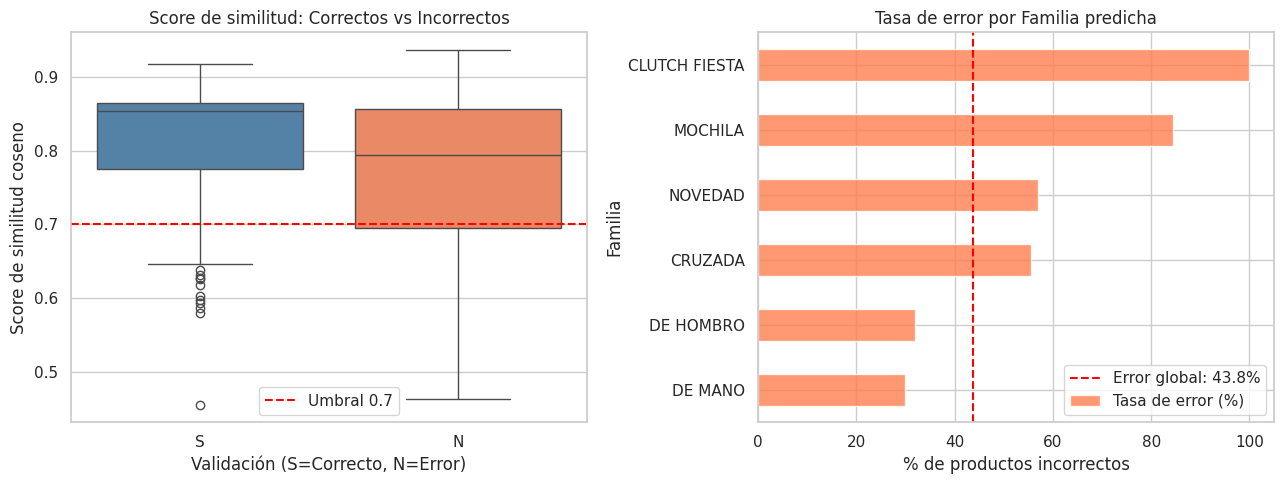

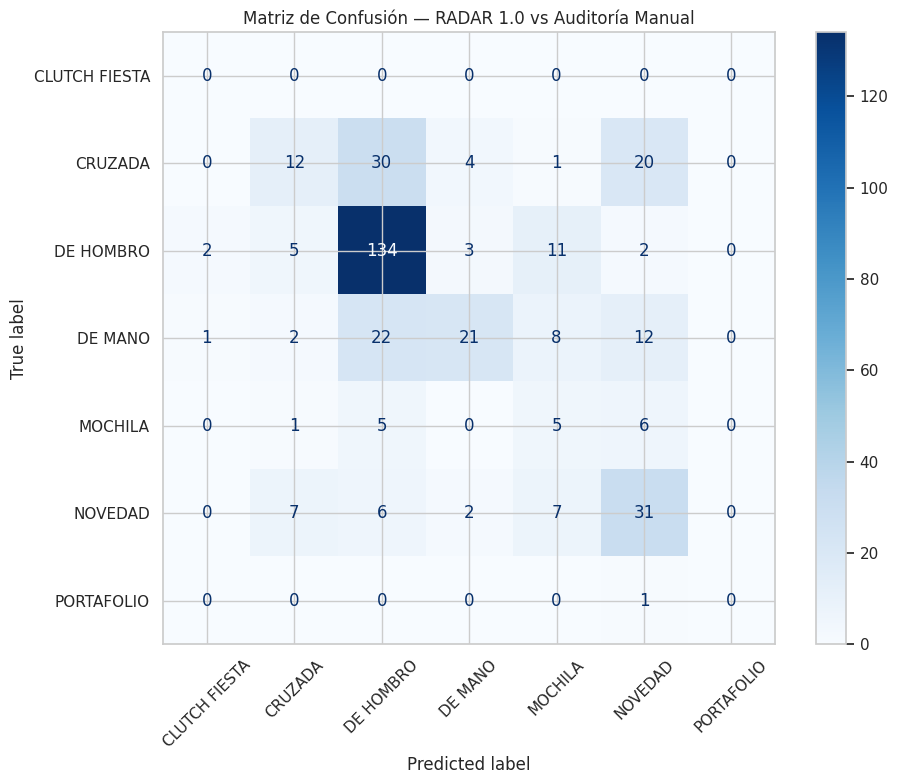


Reporte de clasificación por familia:
               precision    recall  f1-score   support

CLUTCH FIESTA       0.00      0.00      0.00         0
      CRUZADA       0.44      0.18      0.26        67
    DE HOMBRO       0.68      0.85      0.76       157
      DE MANO       0.70      0.32      0.44        66
      MOCHILA       0.16      0.29      0.20        17
      NOVEDAD       0.43      0.58      0.50        53
   PORTAFOLIO       0.00      0.00      0.00         1

     accuracy                           0.56       361
    macro avg       0.34      0.32      0.31       361
 weighted avg       0.58      0.56      0.54       361



In [183]:
# Carga de la auditoría manual y cálculo de métricas de evaluación del baseline
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

df_val1 = pd.read_csv('auditoria_modelo_v2_completo.csv', encoding='latin-1')

# Limpieza de los valores en columnas de validación (remover espacios)
df_val1['Validacion']     = df_val1['Validacion'].str.strip().str.upper()
df_val1['Familia']        = df_val1['Familia'].str.strip()
df_val1['Familia_correcta'] = df_val1['Familia_correcta'].str.strip()

# Verificar si la auditoría fue completada
tiene_validacion = df_val1['Validacion'].isin(['S', 'N']).any()

if not tiene_validacion:
    print("  El archivo de auditoría no tiene validaciones completadas.")
    print("   Llena las columnas 'Validacion' (S/N) y 'Familia_correcta' antes de ejecutar esta celda.")
    print("   Los resultados numéricos del análisis se generarán al volver a correr el notebook.")

else:
    # ── Métricas binarias (correcto/incorrecto) ─────────────────────────────
    n_total    = len(df_val1)
    n_aciertos = (df_val1['Validacion'] == 'S').sum()
    n_errores  = (df_val1['Validacion'] == 'N').sum()
    accuracy   = n_aciertos / n_total * 100

    print(f"{'='*50}")
    print(f"  Resultados de la Auditoría Manual — RADAR 1.0")
    print(f"{'='*50}")
    print(f"  Total auditado:   {n_total}")
    print(f"  Aciertos (S):     {n_aciertos}   ({n_aciertos/n_total*100:.1f}%)")
    print(f"  Errores  (N):     {n_errores}   ({n_errores/n_total*100:.1f}%)")
    print(f"  Efectividad:      {accuracy:.1f}%")
    print(f"  Desempeño mínimo: 95.0%  (AQL 2.5%, ISO 2859-1)")
    print(f"  Dictamen:         {'APROBADO' if n_errores <= 14 else 'RECHAZADO — modelo requiere ajustes'}")
    print(f"{'='*50}")

    # ── Análisis de errores por familia ─────────────────────────────────────
    errores_por_familia = (
        df_val1.groupby('Familia')['Validacion']
        .apply(lambda x: (x == 'N').sum())
        .rename('Errores')
    )
    total_por_familia = df_val1['Familia'].value_counts().rename('Total')
    tasa_error_familia = (errores_por_familia / total_por_familia * 100).round(1).rename('Tasa de error (%)')

    df_error_familia = pd.concat([total_por_familia, errores_por_familia, tasa_error_familia], axis=1).sort_values('Tasa de error (%)', ascending=False)
    print("\nAnálisis de errores por Familia predicha:")
    print(df_error_familia.to_string())

    # ── Score medio por resultado (correcto vs incorrecto) ───────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.boxplot(
        data=df_val1,
        x='Validacion',
        y='score_similitud',
        palette={'S': 'steelblue', 'N': 'coral'},
        ax=axes[0]
    )
    axes[0].set_title("Score de similitud: Correctos vs Incorrectos")
    axes[0].set_xlabel("Validación (S=Correcto, N=Error)")
    axes[0].set_ylabel("Score de similitud coseno")
    axes[0].axhline(threshold, color='red', linestyle='--', label=f'Umbral {threshold}')
    axes[0].legend()

    # Tasa de error por familia
    df_error_familia['Tasa de error (%)'].sort_values(ascending=True).plot(
        kind='barh', ax=axes[1], color='coral', alpha=0.8
    )
    axes[1].axvline(100 - accuracy, color='red', linestyle='--', label=f'Error global: {100-accuracy:.1f}%')
    axes[1].set_title("Tasa de error por Familia predicha")
    axes[1].set_xlabel("% de productos incorrectos")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # ── Matriz de confusión (si hay Familia_correcta para los errores) ────────
    tiene_familia_correcta = df_val1.loc[
        df_val1['Validacion'] == 'N', 'Familia_correcta'
    ].str.len().gt(0).any()

    if tiene_familia_correcta:
        # Construir etiquetas reales: si S → familia predicha; si N → familia correcta
        df_val1['Familia_real'] = df_val1.apply(
            lambda r: r['Familia'] if r['Validacion'] == 'S' else r['Familia_correcta'],
            axis=1
        )

        clases = sorted(df_val1['Familia_real'].unique().tolist() + df_val1['Familia'].unique().tolist())
        clases = sorted(set(clases))

        cm = confusion_matrix(df_val1['Familia_real'], df_val1['Familia'], labels=clases)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)

        fig, ax = plt.subplots(figsize=(10, 8))
        disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
        ax.set_title("Matriz de Confusión — RADAR 1.0 vs Auditoría Manual")
        plt.tight_layout()
        plt.show()

        print("\nReporte de clasificación por familia:")
        print(classification_report(df_val1['Familia_real'], df_val1['Familia'], labels=clases, zero_division=0))
    else:
        print("\n  Columna 'Familia_correcta' vacía — la matriz de confusión estará disponible")
        print("   una vez completada la auditoría con la familia real para los registros incorrectos.")

In [184]:
# Resumen de desempeño del baseline vs mínimos esperados

# Métricas calculadas en celdas anteriores (se usan variables existentes)
score_medio_semantico = df_competencia['score_similitud'].mean()
pct_cobertura         = (df_competencia['score_similitud'] >= threshold).mean() * 100
pct_novedad_total     = (df_competencia['Familia'] == 'NOVEDAD').mean() * 100
retailer_usados       = len(set(sim_matrix.argmax(axis=1)))
pct_catalogo_usado    = retailer_usados / len(df_retailer) * 100

# Resultados de auditoría (se usan si están disponibles, de lo contrario se usan valores hardcodeados)
# Ajusta estos valores si el CSV de auditoría fue completado y rellenado manualmente
EFECTIVIDAD_AUDITADA  = 100 - error_percentage   # % real de la auditoría
N_ERRORES_AUDITADOS   = error_count

print(f"{'='*62}")
print(f"  Tabla de Desempeño — RADAR 1.0 Baseline")
print(f"{'='*62}")
print(f"  {'Métrica':<38} {'Resultado':>10} {'Mínimo':>8}")
print(f"  {'-'*60}")
print(f"  {'Efectividad en auditoría manual':<38} {EFECTIVIDAD_AUDITADA:>9.1f}% {80.0:>7.1f}%")
print(f"  {'Errores auditados (límite AQL: 14)':<38} {N_ERRORES_AUDITADOS:>10} {'≤ 14':>8}")
print(f"  {'Score medio de similitud coseno':<38} {score_medio_semantico:>10.4f} {'>0.60':>8}")
print(f"  {'Cobertura (% con familia asignada)':<38} {pct_cobertura:>9.1f}% {'>50%':>8}")
print(f"  {'% clasificado como NOVEDAD':<38} {pct_novedad_total:>9.1f}% {'<40%':>8}")
print(f"  {'Cobertura catálogo Coppel':<38} {pct_catalogo_usado:>9.1f}% {'>30%':>8}")
print(f"{'='*62}")

# Veredicto por métrica
print("\nDiagnóstico por métrica:")
checks = [
    ("Efectividad mínima 80%",      EFECTIVIDAD_AUDITADA >= 80.0),
    ("Score medio > 0.60",          score_medio_semantico > 0.60),
    ("Cobertura > 50%",             pct_cobertura > 50.0),
    ("NOVEDAD < 40%",               pct_novedad_total < 40.0),
    ("Catálogo Coppel usado > 30%", pct_catalogo_usado > 30.0),
]
for nombre, cumple in checks:
    estado = "Cumple" if cumple else "No cumple"
    print(f"  {nombre:<35}: {estado}")

  Tabla de Desempeño — RADAR 1.0 Baseline
  Métrica                                 Resultado   Mínimo
  ------------------------------------------------------------
  Efectividad en auditoría manual             56.2%    80.0%
  Errores auditados (límite AQL: 14)            158     ≤ 14
  Score medio de similitud coseno            0.8050    >0.60
  Cobertura (% con familia asignada)          89.5%     >50%
  % clasificado como NOVEDAD                   5.8%     <40%
  Cobertura catálogo Coppel                   17.8%     >30%

Diagnóstico por métrica:
  Efectividad mínima 80%             : No cumple
  Score medio > 0.60                 : Cumple
  Cobertura > 50%                    : Cumple
  NOVEDAD < 40%                      : Cumple
  Catálogo Coppel usado > 30%        : No cumple


Resultados Estadísticos de la Muestra 1

Tras procesar la muestra de control:

Registros Totales: 361

Aciertos (S): 203

Errores (N): 158

Tasa de Efectividad: 56%

Mejora ligeramente el rendimiento del modelo respecto al Baseline.

# Parte 3: Elección y conceptualización de diseño para la entrega final

Posterior a que el modelo haya alcanzado la confiabilidad deseada, para transformar las salidas (similitud de cosenos y generación de clusters) en decisiones comerciales, se decidió complementar el proyecto con una estrategia de visualización y arquitectura analítica, para evitar la saturación de tablas planas y ayudar a que el usuario se centre en el descubrimiento visual de los insights relevantes resultantes de la aplicación del modelo.

### Selección de la herramienta

Se evaluaron dos opciones: 1) operar los resultados desde una Plataforma / Producto de datos dedicado (UI a medida en Web App, por ej. Streamlit/React), o 2) desarrollar un Reporte Dinámico (Power BI / Tableau) para la visualización.

Contemplando costos de desarrollo, curva de adopción/capacitación del personal de Coppel y dado que la fecha de entrega del proyecto está fijada para el siguiente mes, la opción más viable y congruente es enfocarnos en un Reporte Dinámico, por diversas razones:

+ Time-to-Market: Desarrollar una Plataforma a la medida (opción 1) en menos de 30 días introduce un riesgo crítico de calidad en el software y rebasa la capacidad de testing. En cambio, el Reporte Dinámico permite consumir directamente las tablas de salida del modelo (almacenadas en el Data Warehouse) de forma inmediata.
+ Adopción inmediata: Al entregar el reporte en un ecosistema analítico que el equipo comercial ya domina, garantizamos que el análisis se ejecute en el ciclo comercial de cada mes, eliminando la resistencia al cambio.
+ Estrategia evolutiva: Este Reporte Dinámico funcionará para Coppel como un Producto Mínimo Viable (MVP) de alta fidelidad. Permitirá madurar las reglas de negocio y los umbrales de similitud del modelo durante los primeros 3 a 6 meses para, posteriormente y con requerimientos validados, migrar hacia una plataforma dedicada (si el negocio exige automatización de flujos operativos o pricing dinámico diario).

### Elementos

1. Vista Macro (Cobertura global del catálogo vs. competencia)


Esta vista permite al Gerente de Categoría entender su postura de mercado en un solo vistazo. Por ejemplo:
+ Gráfico de matriz de árbol (Treemap) de cobertura jerárquica: El tamaño de cada rectángulo representa el volumen total de productos de la competencia en esa Familia/Cluster.
El color del rectángulo (escala divergente de rojo a verde) representa el Índice de cobertura de surtido homologado.
Uso estratégico: Los rectángulos grandes y rojos se identifican instantáneamente como las categorías críticas donde la competencia nos domina y no tenemos oferta.
+ Gráfico de barras normalizadas flotantes (bullet chart):
Para cada categoría principal, muestra una barra con el total de SKUs de la competencia. Dentro, una línea objetivo marca el surtido propio actual.
La barra se segmenta internamente en tres colores fijos que representan el Market Share visual de los competidores analizados, permitiendo ver qué competidor lidera cada frente.

2. Vista Micro (Análisis de competitividad de Precios por Tiers)

Diseñada para el Comprador operativo que necesita corregir desviaciones específicas de precio. Por ejemplo:
+ Matriz de confusión térmica (heatmap de coexistencia de Tiers):
Eje Y: Tiers Internos (Bajo, Medio, Alto). Eje X: Tiers de la Competencia asignados por el modelo NLP.
Las celdas de la diagonal principal (Bajo-Bajo, Medio-Medio, Alto-Alto) representan una alineación correcta. Las celdas fuera de la diagonal muestran la asimetría.
Uso estratégico: Al hacer clic en la celda "Interno: Alto vs. Competencia: Bajo" (la zona de mayor peligro de pérdida de venta), el dashboard filtra automáticamente el listado de SKUs específicos para reajuste de precios inmediato.
+ Gráfico de dispersión (scatter plot) de Confianza vs Desviación:
Eje X: Similitud de Cosenos.
Eje Y: Índice de Competitividad de Precio (centrado en 100).
Cada punto es un SKU. El cuadrante superior derecho (Alta similitud / Precio interno mucho más alto) muestra productos idénticos dónde estamos fuera de mercado. El cuadrante inferior derecho (Alta similitud / Precio bajo) muestra oportunidades para incrementar el margen si el objetivo no es volumen.

### Principales KPIs

Para lograr de manera exitosa los objetivos y elementos que componen el reporte, se debe contar con una estructura base, compuesta por los siguientes KPIs:

1. Índice de cobertura

Lógica de negocio: (Número de SKUs internos con matching válido / Total de SKUs únicos detectados en la competencia) x 100.

Objetivo: Identificar "puntos ciegos" en el catálogo. Permite al comprador expandir el surtido o negociar exclusividades en familias donde la competencia nos supera en variedad.

2. Penetración por Tier de Precio (DST)

Lógica de negocio: (SKUs internos en Tier bajo/medio/alto con match / Total de SKUs de la competencia clasificados en Tier bajo/medio/alto por el modelo) x 100 (Calculado individualmente para cada Familia).

Objetivo: Evaluar la consistencia de la propuesta de valor. Si la competencia tiene alta densidad en el Tier Bajo y nosotros en el Tier Alto para la misma familia, el comprador debe decidir si rebalancear la arquitectura de precios o reposicionar las marcas en esa familia.

3. Índice de competitividad de Precio

Lógica de negocio: (Precio SKU Interno / Precio SKU competidor correspondiente) x 100 (Agrupado por categoría NLP).

Objetivo: Medir la competitividad pura en los productos idénticos o altamente sustitutos. Un índice > 100 indica que somos más caros. Decisión: Activar rebajas dinámicas, promociones, o exigir mejores costos al proveedor (sell-in).

4. Brechas de surtido

Lógica de negocio: Conteo de SKUs de la competencia con matching inválido (Novedades).

Objetivo: Alerta directa de innovación u oportunidad de mercado. El comprador recibe un listado depurado de productos de la competencia que nosotros ni siquiera tenemos mapeados.

# Conclusiones

Se logró identificar cúales son las caracteristicas principales que influyen en el comportamiento del modelo para futuros movimientos. Además de incluir una visión de cara a la entrega final para contruir en paralelo con la mejora de los resultados obtenidos.


In [185]:
import nbformat

def fix_avance_notebook(input_file, output_file=None):
    """
    Elimina específicamente los metadatos de widgets corruptos del notebook del equipo.
    """
    if output_file is None:
        output_file = input_file

    try:
        # Cargar el notebook preservando la estructura original
        with open(input_file, 'r', encoding='utf-8') as f:
            nb = nbformat.read(f, as_version=4)

        # Identificar y eliminar la raíz del problema
        if 'widgets' in nb.metadata:
            print(f"[*] Conflicto encontrado en '{input_file}'.")
            # El error 'state key is missing' ocurre dentro de esta rama
            del nb.metadata['widgets']
            print("[✓] Metadatos de widgets eliminados correctamente.")
        else:
            print("[!] El archivo no contiene metadatos de widgets. Podría ser otro error de esquema.")

        # Guardar el archivo limpio
        with open(output_file, 'w', encoding='utf-8') as f:
            nbformat.write(nb, f)

        print(f"[FIN] Archivo guardado como: {output_file}")

    except Exception as e:
        print(f"[ERROR] Error crítico al procesar el archivo: {e}")

if __name__ == "__main__":

    fix_avance_notebook('Avance4_Equipo_47.ipynb')

[ERROR] Error crítico al procesar el archivo: [Errno 2] No such file or directory: 'Avance4_Equipo_47.ipynb'
